# Neural Image Caption Generation
## Sinh Mô Tả Ảnh Tự Động với Deep Learning (PyTorch + ResNet-101 + Bahdanau Attention)

---

### Tóm Tắt

Dự án cài đặt hệ thống **Image Captioning** — tự động sinh câu mô tả tiếng Anh cho ảnh,
sử dụng kiến trúc **Encoder-Decoder với Bahdanau Attention** và **ResNet-101** làm backbone.

```
Ảnh (224×224×3)
    ──► ResNet-101 Encoder    ──► Feature Grid  (B, 49, 2048)
    ──► Bahdanau Attention    ──► Context vector (B, 2048)
    ──► LSTM Decoder 512      ──► Logits        (B, vocab_size)
    ──► Beam Search (k=5)     ──► Caption text
```

### So Sánh ResNet-101 vs VGG16 (phiên bản trước)

| Thành phần        | VGG16 (phiên bản 1)        | ResNet-101 (phiên bản này)         |
|-------------------|----------------------------|------------------------------------|
| Backbone          | VGG16 (conv5_3)            | **ResNet-101 (layer4)**            |
| Feature shape     | (B, 49, 512)               | **(B, 49, 2048)**                  |
| Backbone params   | ~14.7M                     | **~42.5M**                         |
| Top-1 ImageNet    | 71.6%                      | **77.4%**                          |
| LSTM hidden size  | 512                        | 512                                |
| Word Embedding    | GloVe 300d fine-tune       | GloVe 300d fine-tune               |
| Optimizer         | AdamW lr=1e-4              | AdamW lr=1e-4                      |
| Loss              | CrossEntropy + smoothing   | CrossEntropy + smoothing           |
| Inference         | Beam Search width=5        | Beam Search width=5                |

**Dataset:** Flickr30k — 31,783 ảnh × 5 captions/ảnh = 158,915 cặp ảnh-mô tả  
**Mục tiêu:** BLEU-4 > 0.22  (VGG16 version target: 0.20)

---

### Mục Lục

| Cell | Nội dung |
|:----:|----------|
| 2  | Thiết lập Môi trường |
| 3  | Kiểm tra Package và GPU |
| 4  | Import Thư viện |
| 5  | Cấu hình và Hằng số |
| 6  | Khám phá Dataset (EDA) |
| 7  | Trích xuất Features ResNet-101 |
| 8  | Parse Captions |
| 9  | Làm sạch Captions |
| 10 | Tokenization và GloVe Embeddings |
| 11 | Tạo Training Samples (PyTorch Dataset) |
| 12 | Xây dựng Kiến trúc Model |
| 13 | Huấn luyện Model |
| 14 | Đánh giá với BLEU Score |
| 15 | Demo – Sinh Caption cho Ảnh Mới |


## Cell 2: Thiết lập Thư mục và Chẩn đoán Môi trường

**Mục đích:**
- Tự động tìm thư mục gốc của project (hoạt động cả trong VS Code lẫn Jupyter)
- Thiết lập `WORK_DIR` để lưu dataset, features, model
- In thông tin môi trường cho báo cáo


In [1]:
# ─── BƯỚC 1: THIẾT LẬP THƯ MỤC ───────────────────────────────────────────────
from pathlib import Path
import os, platform, sys, subprocess

NOTEBOOK_FILENAME = 'ImageCaptioning_Flickr30k_ResNet101.ipynb'

def find_project_root(start: Path) -> Path:
    """Tìm thư mục chứa notebook, kể cả khi cwd nằm trong subfolder."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / NOTEBOOK_FILENAME).exists():
            return candidate
        # fallback: tìm theo notebook VGG16 cũng được
        if (candidate / 'ImageCaptioning_Flickr30k_VGG16.ipynb').exists():
            return candidate
    return start.resolve()

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
WORK_DIR = PROJECT_ROOT / 'workspace'
WORK_DIR.mkdir(parents=True, exist_ok=True)

IS_MACOS         = platform.system() == 'Darwin'
IS_APPLE_SILICON = IS_MACOS and platform.machine() == 'arm64'

# ─── BƯỚC 2: IN THÔNG TIN MÔI TRƯỜNG ─────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  THIẾT LẬP MÔI TRƯỜNG – ResNet-101 Version")
print(SEP)
print(f"  Project root   : {PROJECT_ROOT}")
print(f"  Work dir       : {WORK_DIR}")
print(f"  Python         : {sys.version.split()[0]}")
print(f"  Executable     : {sys.executable}")
print(f"  OS             : {platform.system()} {platform.release()}")
print(f"  Architecture   : {platform.machine()}")
print(f"  Apple Silicon  : {IS_APPLE_SILICON}")

conda_env = os.environ.get('CONDA_DEFAULT_ENV', 'N/A')
venv      = os.environ.get('VIRTUAL_ENV', 'N/A')
print(f"  Conda env      : {conda_env}")
print(f"  Virtual env    : {venv}")

# ─── BƯỚC 3: KIỂM TRA CÁC THƯ MỤC CẦN THIẾT ─────────────────────────────────
subdirs = ['Flicker30k_Dataset', 'models']
print(f"\n  Trạng thái thư mục con trong workspace/:")
for sub in subdirs:
    path   = WORK_DIR / sub
    exists = path.exists()
    n_files = len(list(path.iterdir())) if exists else 0
    status  = f"✅  {n_files} files" if exists else "❌  Chưa có"
    print(f"    {sub:<25} {status}")

glove_files = ['glove.6B.300d.txt', 'glove.6B.100d.txt']
print(f"\n  GloVe embeddings (project root):")
for gf in glove_files:
    path   = PROJECT_ROOT / gf
    status = f"✅  {path.stat().st_size // 1024 // 1024} MB" if path.exists() else "❌  Chưa có"
    print(f"    {gf:<25} {status}")
print(SEP)


  THIẾT LẬP MÔI TRƯỜNG – ResNet-101 Version
  Project root   : /Applications/Python_AI/Neural_Image_Caption_Generation
  Work dir       : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace
  Python         : 3.10.20
  Executable     : /opt/anaconda3/envs/tf-metal/bin/python
  OS             : Darwin 25.3.0
  Architecture   : arm64
  Apple Silicon  : True
  Conda env      : tf-metal
  Virtual env    : N/A

  Trạng thái thư mục con trong workspace/:
    Flicker30k_Dataset        ✅  31784 files
    models                    ✅  12 files

  GloVe embeddings (project root):
    glove.6B.300d.txt         ✅  989 MB
    glove.6B.100d.txt         ✅  331 MB


## Cell 3: Kiểm tra Package và Phát hiện Thiết bị (GPU/MPS/CPU)

**Mục đích:**
- Cài tự động các package còn thiếu
- Phát hiện thiết bị tính toán: NVIDIA CUDA / Apple MPS / CPU
- In thông tin chi tiết về GPU nếu có


In [2]:
# ─── BƯỚC 1: KIỂM TRA VÀ CÀI PACKAGE ────────────────────────────────────────
import importlib, importlib.util

REQUIRED_PACKAGES = {
    'torch'       : 'torch',
    'torchvision' : 'torchvision',
    'PIL'         : 'pillow',
    'nltk'        : 'nltk',
    'matplotlib'  : 'matplotlib',
    'tqdm'        : 'tqdm',
    'numpy'       : 'numpy',
}

missing = []
for module, pkg in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module) is None:
        missing.append(pkg)

if missing:
    print(f"Đang cài các package còn thiếu: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
    print("✅  Cài đặt xong.")
else:
    print("✅  Tất cả package đã sẵn sàng.")

# ─── BƯỚC 2: DOWNLOAD NLTK DATA ──────────────────────────────────────────────
import nltk
for resource in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# ─── BƯỚC 3: PHÁT HIỆN THIẾT BỊ ─────────────────────────────────────────────
import torch

SEP = "=" * 65
print(f"\n{SEP}")
print("  THÔNG TIN THIẾT BỊ TÍNH TOÁN")
print(SEP)
print(f"  PyTorch version  : {torch.__version__}")

if torch.cuda.is_available():
    device      = torch.device('cuda')
    gpu_name    = torch.cuda.get_device_name(0)
    gpu_mem_gb  = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"  Device           : NVIDIA CUDA GPU")
    print(f"  GPU Name         : {gpu_name}")
    print(f"  GPU Memory       : {gpu_mem_gb:.1f} GB")
    print(f"  CUDA Version     : {torch.version.cuda}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"  Device           : Apple MPS (Metal Performance Shaders)")
    print(f"  Chip             : Apple Silicon (ARM64)")
    print(f"  MPS Built        : {torch.backends.mps.is_built()}")
else:
    device = torch.device('cpu')
    import multiprocessing
    print(f"  Device           : CPU")
    print(f"  CPU Cores        : {multiprocessing.cpu_count()}")

print(f"  ► Selected       : {str(device).upper()}")
print(SEP)


✅  Tất cả package đã sẵn sàng.

  THÔNG TIN THIẾT BỊ TÍNH TOÁN
  PyTorch version  : 2.11.0
  Device           : Apple MPS (Metal Performance Shaders)
  Chip             : Apple Silicon (ARM64)
  MPS Built        : True
  ► Selected       : MPS


## Cell 4: Import Tất cả Thư viện

**Mục đích:** Tập trung toàn bộ import vào một cell duy nhất.

| Nhóm | Thư viện |
|------|----------|
| 1 – Tính toán cơ bản | `os`, `sys`, `re`, `json`, `pickle`, `math`, `random`, `collections` |
| 2 – Xử lý văn bản | `re`, `string`, `nltk` |
| 3 – Xử lý file/ảnh | `pathlib`, `PIL` |
| 4 – PyTorch (Deep Learning) | `torch`, `torch.nn`, `torchvision`, `tqdm` |
| 5 – Đánh giá & Trực quan | `matplotlib`, `numpy`, `nltk.translate.bleu_score` |


In [3]:
# ─── NHÓM 1: THƯ VIỆN TÍNH TOÁN CƠ BẢN ─────────────────────────────────────
import os, sys, re, json, math, random, gc, time
import pickle
import string
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

# ─── NHÓM 2: XỬ LÝ VĂN BẢN ──────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# ─── NHÓM 3: XỬ LÝ FILE VÀ ẢNH ──────────────────────────────────────────────
from PIL import Image

# ─── NHÓM 4: PYTORCH – DEEP LEARNING FRAMEWORK ───────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as tv_models
import torchvision.transforms as transforms
from tqdm import tqdm

# ─── NHÓM 5: ĐÁNH GIÁ VÀ TRỰC QUAN ──────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi'    : 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'font.family'   : 'DejaVu Sans',
})

# ─── TỔNG KẾT ─────────────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TỔNG KẾT IMPORT")
print(SEP)
libs = {
    'numpy'      : np.__version__,
    'torch'      : torch.__version__,
    'torchvision': __import__('torchvision').__version__,
    'PIL'        : Image.__version__,
    'matplotlib' : matplotlib.__version__,
    'nltk'       : nltk.__version__,
}
for lib, ver in libs.items():
    print(f"  {lib:<15} v{ver}")
print(f"  Device: {device}")
print(SEP)


  TỔNG KẾT IMPORT
  numpy           v1.26.4
  torch           v2.11.0
  torchvision     v0.26.0
  PIL             v12.1.1
  matplotlib      v3.10.8
  nltk            v3.9.3
  Device: mps


## Cell 5: Cấu hình và Hằng số

**Mục đích:** Tập trung **tất cả tham số** vào một nơi — tránh "magic numbers".

| Phần | Nội dung |
|------|----------|
| 1 – Đường dẫn | Vị trí file dataset, features (resnet101), model |
| 2 – ResNet-101 | Input size, feature dimension (2048) |
| 3 – Model | LSTM units, embedding dim, dropout |
| 4 – Training | Batch size, epochs, learning rate, scheduler |

> ⚠️ **Lưu ý:** Feature file và model checkpoint dùng prefix `resnet101` để **không ghi đè** file của VGG16 version.


In [7]:
# ─── PHẦN 1: ĐƯỜNG DẪN FILE VÀ FOLDER ───────────────────────────────────────
IMAGE_DIR    = WORK_DIR / 'Flicker30k_Dataset'
CAPTIONS_CSV = WORK_DIR / 'results.csv'

# ⚠️ Dùng prefix resnet101 — không đè lên artifacts của VGG16
FEATURES_PATH  = WORK_DIR / 'features_resnet101_flickr30k.pkl'
FEAT_NPY_DIR   = WORK_DIR / 'features_resnet101_npy'   # lazy loading dir
DESC_PATH      = WORK_DIR / 'descriptions_flickr30k.txt'        # dùng chung
TOKENIZER_PATH = WORK_DIR / 'tokenizer_flickr30k.pkl'           # dùng chung
SPLITS_PATH    = WORK_DIR / 'flickr30k_splits.json'             # dùng chung
MODEL_DIR      = WORK_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH     = MODEL_DIR / 'caption_resnet101_flickr30k_best.pt'
HISTORY_PATH   = MODEL_DIR / 'training_history_resnet101_flickr30k.json'

# GloVe: thử 300d trước, fallback sang 100d
GLOVE_SEARCH_PATHS = [
    PROJECT_ROOT / 'glove.6B.300d.txt',
    PROJECT_ROOT / 'glove.6B' / 'glove.6B.300d.txt',
    WORK_DIR / 'glove' / 'glove.6B.300d.txt',
    PROJECT_ROOT / 'glove.6B.100d.txt',
    PROJECT_ROOT / 'glove.6B' / 'glove.6B.100d.txt',
    WORK_DIR / 'glove.6B.100d.txt',
]

# ─── PHẦN 2: THAM SỐ RESNET-101 ──────────────────────────────────────────────
IMG_SIZE     = 224       # ResNet-101 input size
FEATURE_SIZE = 2048      # ResNet-101 layer4 output channels (vs 512 của VGG16)
NUM_REGIONS  = 49        # 7×7 spatial grid (giống VGG16)

# ─── PHẦN 3: THAM SỐ MODEL ────────────────────────────────────────────────────
VOCAB_SIZE      = 10_000
MAX_LENGTH      = 25    # giảm từ 35→25: tiết kiệm ~28% thời gian/epoch
EMBED_DIM       = 300    # GloVe 300d
HIDDEN_SIZE     = 512    # LSTM hidden units
DROPOUT         = 0.5
EMBED_TRAINABLE = True

# ─── PHẦN 4: THAM SỐ TRAINING ─────────────────────────────────────────────────
BATCH_SIZE          = 32    # giảm từ 64 → 32 để tiết kiệm RAM (16 GB)
EPOCHS              = 10
LEARNING_RATE       = 1e-4
WEIGHT_DECAY        = 1e-4
GRAD_CLIP           = 5.0
LABEL_SMOOTHING     = 0.1
LR_PATIENCE         = 3
LR_FACTOR           = 0.5
EARLY_STOP_PATIENCE = 3
BEAM_WIDTH          = 5
FORCE_RETRAIN       = True

# ─── PHẦN 5: SPLIT SETTINGS ───────────────────────────────────────────────────
SPLIT_SEED = 42
N_VAL      = 1_014
N_TEST     = 1_000

# ─── TỔNG KẾT ─────────────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TỔNG KẾT CẤU HÌNH – RESNET-101 + FLICKR30K")
print(SEP)
sections = {
    "BACKBONE": {
        "Model"          : "ResNet-101 (layer4, no avgpool/fc)",
        "Feature shape"  : f"(B, {NUM_REGIONS}, {FEATURE_SIZE})  ← 49×2048",
        "Comparison"     : "VGG16 was (B, 49, 512) — 4× more channels",
    },
    "DATASET": {
        "Dataset"        : "Flickr30k (31,783 ảnh × 5 captions)",
        "Features file"  : FEATURES_PATH.name,
        "Model file"     : MODEL_PATH.name,
    },
    "MODEL": {
        "Vocab size"     : f"{VOCAB_SIZE:,}",
        "Embed dim"      : f"{EMBED_DIM}d (GloVe fine-tune)",
        "LSTM hidden"    : HIDDEN_SIZE,
        "Dropout"        : DROPOUT,
    },
    "TRAINING": {
        "Batch size"     : BATCH_SIZE,
        "Epochs"         : EPOCHS,
        "Learning rate"  : LEARNING_RATE,
        "Grad clip"      : GRAD_CLIP,
        "Early stop"     : f"patience={EARLY_STOP_PATIENCE}",
    },
}
for section, params in sections.items():
    print(f"\n  [{section}]")
    for k, v in params.items():
        print(f"    {k:<18} : {v}")
print(f"\n  FORCE_RETRAIN : {FORCE_RETRAIN}")
print(SEP)


  TỔNG KẾT CẤU HÌNH – RESNET-101 + FLICKR30K

  [BACKBONE]
    Model              : ResNet-101 (layer4, no avgpool/fc)
    Feature shape      : (B, 49, 2048)  ← 49×2048
    Comparison         : VGG16 was (B, 49, 512) — 4× more channels

  [DATASET]
    Dataset            : Flickr30k (31,783 ảnh × 5 captions)
    Features file      : features_resnet101_flickr30k.pkl
    Model file         : caption_resnet101_flickr30k_best.pt

  [MODEL]
    Vocab size         : 10,000
    Embed dim          : 300d (GloVe fine-tune)
    LSTM hidden        : 512
    Dropout            : 0.5

  [TRAINING]
    Batch size         : 32
    Epochs             : 10
    Learning rate      : 0.0001
    Grad clip          : 5.0
    Early stop         : patience=3

  FORCE_RETRAIN : True


## Cell 6: Khám phá Dataset – Exploratory Data Analysis (EDA)

**Mục đích:** Kiểm tra dữ liệu và hiểu phân phối trước khi training.

| Phần | Nội dung |
|------|----------|
| 1 | Kiểm tra file ảnh và captions |
| 2 | Hiển thị 4 ảnh mẫu ngẫu nhiên |
| 3 | Phân tích kích thước ảnh (4 biểu đồ) |
| 4 | Phân tích captions thô |


  PART 1: IMAGE FILE CHECK – FLICKR30K
  Image dir      : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/Flicker30k_Dataset
  Image count    : 31,783
  Captions file  : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/results.csv
  CSV size       : 12.7 MB
  Corrupt (50 sample) : 0


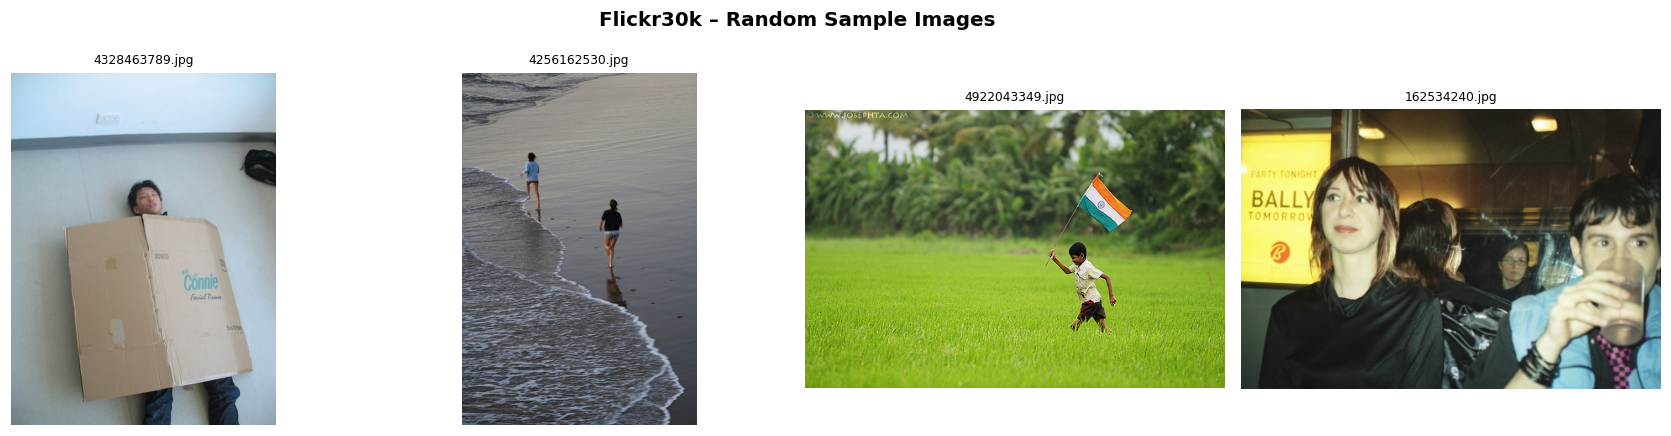

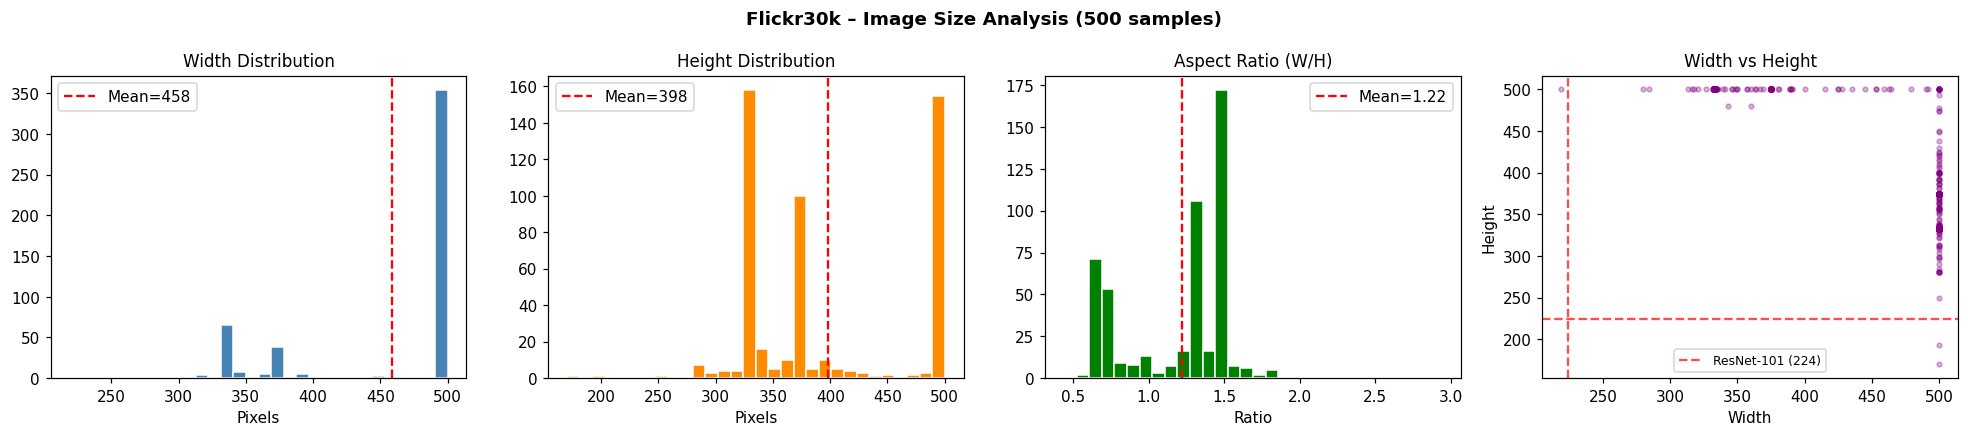


  PART 4: CAPTIONS ANALYSIS
  Total lines (incl. header) : 158,916
  Sample lines:
    1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out i
    1000092795.jpg| 1| Two young , White males are outside near many bushes .
    1000092795.jpg| 2| Two men in green shirts are standing in a yard .


In [8]:
# ─── PHẦN 1: KIỂM TRA FILE ẢNH ───────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PART 1: IMAGE FILE CHECK – FLICKR30K")
print(SEP)

assert IMAGE_DIR.exists(),    f"❌ Not found: {IMAGE_DIR}"
assert CAPTIONS_CSV.exists(), f"❌ Not found: {CAPTIONS_CSV}"

image_files = sorted([f for f in IMAGE_DIR.iterdir()
                       if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
print(f"  Image dir      : {IMAGE_DIR}")
print(f"  Image count    : {len(image_files):,}")
print(f"  Captions file  : {CAPTIONS_CSV}")
print(f"  CSV size       : {CAPTIONS_CSV.stat().st_size / 1024 / 1024:.1f} MB")

corrupt = 0
for fpath in image_files[:50]:
    try:
        Image.open(fpath).verify()
    except Exception:
        corrupt += 1
print(f"  Corrupt (50 sample) : {corrupt}")

# ─── PHẦN 2: HIỂN THỊ 4 ẢNH MẪU ──────────────────────────────────────────────
sample_imgs = random.sample(image_files, 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Flickr30k – Random Sample Images', fontsize=13, fontweight='bold')
for ax, fpath in zip(axes, sample_imgs):
    img = Image.open(fpath).convert('RGB')
    ax.imshow(img); ax.set_title(fpath.name[:20], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

# ─── PHẦN 3: PHÂN TÍCH KÍCH THƯỚC ẢNH ────────────────────────────────────────
sample_paths = random.sample(image_files, 500)
widths, heights, ratios = [], [], []
for fpath in sample_paths:
    try:
        w, h = Image.open(fpath).size
        widths.append(w); heights.append(h); ratios.append(w / h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Flickr30k – Image Size Analysis (500 samples)', fontweight='bold')

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution'); axes[0].set_xlabel('Pixels')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean={np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Pixels')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean={np.mean(heights):.0f}')
axes[1].legend()

axes[2].hist(ratios, bins=30, color='green', edgecolor='white')
axes[2].set_title('Aspect Ratio (W/H)'); axes[2].set_xlabel('Ratio')
axes[2].axvline(np.mean(ratios), color='red', linestyle='--', label=f'Mean={np.mean(ratios):.2f}')
axes[2].legend()

axes[3].scatter(widths, heights, alpha=0.3, s=10, color='purple')
axes[3].axhline(224, color='red', linestyle='--', alpha=0.7, label='ResNet-101 (224)')
axes[3].axvline(224, color='red', linestyle='--', alpha=0.7)
axes[3].set_title('Width vs Height'); axes[3].legend(fontsize=8)
axes[3].set_xlabel('Width'); axes[3].set_ylabel('Height')

plt.tight_layout(); plt.show()

# ─── PHẦN 4: PHÂN TÍCH CAPTIONS THÔ ─────────────────────────────────────────
with open(CAPTIONS_CSV, encoding='utf-8') as f:
    lines = f.readlines()

print(f"\n{SEP}")
print("  PART 4: CAPTIONS ANALYSIS")
print(SEP)
print(f"  Total lines (incl. header) : {len(lines):,}")
print(f"  Sample lines:")
for line in lines[1:4]:
    print(f"    {line.strip()[:90]}")


## Cell 7: Trích xuất Features bằng ResNet-101 (PyTorch)

**Mục đích:** Chuyển mỗi ảnh từ pixel `(224×224×3)` → vector đặc trưng lưới `(49×2048)`.

```
ResNet-101 Architecture (torchvision):
  Input      : (B, 3, 224, 224)
  conv1      : (B, 64, 112, 112)
  layer1–3   : feature extraction
  layer4     : (B, 2048, 7, 7)    ← dùng layer này
  avgpool    : (B, 2048, 1, 1)    ← BỎ QUA
  fc         : (B, 1000)          ← BỎ QUA
  Reshape    : (B, 2048, 7, 7) → (B, 49, 2048)  ← SPATIAL INFO cho Attention
```

**So sánh với VGG16:**
| | VGG16 | ResNet-101 |
|--|-------|-----------|
| Feature channels | 512 | **2048** (4× nhiều hơn) |
| Spatial positions | 49 | 49 (giống nhau) |
| Thông tin ngữ nghĩa | Tốt | **Tốt hơn** (deeper residual) |

| Bước | Nội dung |
|------|----------|
| 1 | Tải ResNet-101 pre-trained (ImageNet V2) |
| 2 | Cắt bỏ avgpool + fc, giữ layer4 |
| 3 | Trích xuất features cho tất cả ảnh |
| 4 | Lưu ra file pickle |
| 5 | Kiểm tra kết quả (4 biểu đồ) |


  RESNET-101 FEATURE EXTRACTION (PYTORCH)
  ✅ Features found: /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/features_resnet101_flickr30k.pkl
  Loading features from file...
  Loaded 31,783 images. Sample shape: (49, 2048)

  FEATURE VERIFICATION


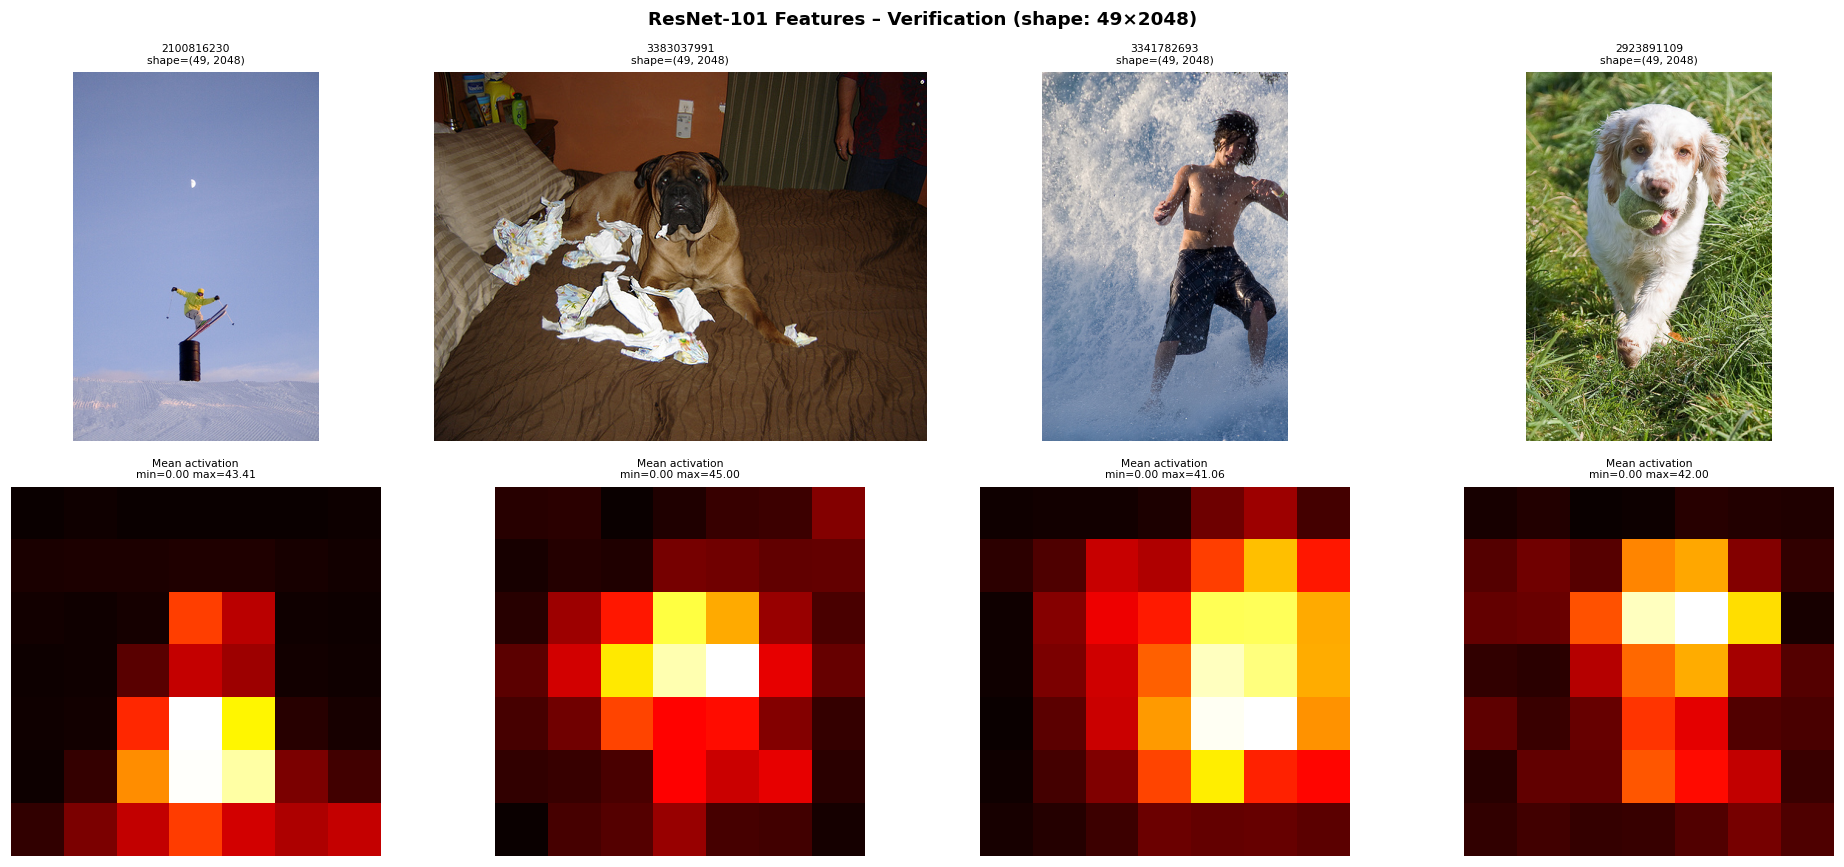

  Feature shape : (49, 2048)
  Total images  : 31,783


In [15]:
# ─── BƯỚC 1: TẢI RESNET-101 PRE-TRAINED ──────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  RESNET-101 FEATURE EXTRACTION (PYTORCH)")
print(SEP)

if FEATURES_PATH.exists() and not FORCE_RETRAIN:
    print(f"  ✅ Features found: {FEATURES_PATH}")
    print("  Loading features from file...")
    with open(FEATURES_PATH, 'rb') as f:
        features_conv = pickle.load(f)
    sample_shape = list(features_conv.values())[0].shape
    print(f"  Loaded {len(features_conv):,} images. Sample shape: {sample_shape}")
    assert sample_shape == (NUM_REGIONS, FEATURE_SIZE), (
        f"❌ Shape mismatch! Expected ({NUM_REGIONS}, {FEATURE_SIZE}), got {sample_shape}. "
        "Set FORCE_RETRAIN=True to re-extract."
    )
else:
    print("  Loading ResNet-101 pre-trained (ImageNet V2 weights)...")

    # ─── BƯỚC 2: CẮT BỎ AVGPOOL + FC, GIỮ LẠI LAYER4 ───────────────────────
    # ResNet-101 children: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc
    resnet101 = tv_models.resnet101(weights=tv_models.ResNet101_Weights.IMAGENET1K_V2)
    # Lấy tất cả layer trừ 2 cái cuối (avgpool + fc)
    extractor = nn.Sequential(*list(resnet101.children())[:-2])
    extractor = extractor.to(device).eval()

    for param in extractor.parameters():
        param.requires_grad = False

    total_params = sum(p.numel() for p in extractor.parameters())
    print(f"  ResNet-101 extractor (no avgpool/fc):")
    print(f"    Total params : {total_params:,}")
    print(f"    Output shape : (B, 2048, 7, 7) → reshape → (B, 49, 2048)")

    # ─── TRANSFORM (ImageNet chuẩn) ──────────────────────────────────────────
    resnet_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

    image_list = sorted([f for f in IMAGE_DIR.iterdir()
                         if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    print(f"\n  Trích xuất features cho {len(image_list):,} ảnh...")
    start_time = time.time()

    features_conv = {}
    errors = []

    with torch.no_grad():
        for fpath in tqdm(image_list, desc='Extracting ResNet-101'):
            try:
                img    = Image.open(fpath).convert('RGB')
                tensor = resnet_transform(img).unsqueeze(0).to(device)  # (1,3,224,224)
                feat   = extractor(tensor)                               # (1,2048,7,7)
                feat   = feat.squeeze(0)                                 # (2048,7,7)
                feat   = feat.permute(1, 2, 0)                          # (7,7,2048)
                feat   = feat.reshape(NUM_REGIONS, FEATURE_SIZE)        # (49,2048)
                feat   = feat.cpu().numpy().astype('float16')   # float16: ~6 GB vs float32: ~12 GB
                img_id = fpath.stem
                features_conv[img_id] = feat
            except Exception as e:
                errors.append((fpath.name, str(e)))

    elapsed = time.time() - start_time
    print(f"  Done: {len(features_conv):,} images in {elapsed:.1f}s  ({elapsed/len(features_conv)*1000:.1f}ms/img)")
    if errors:
        print(f"  ⚠️  Errors: {len(errors)} images — {errors[:3]}")

    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(features_conv, f)
    size_mb = FEATURES_PATH.stat().st_size / 1024 / 1024
    print(f"  ✅ Saved → {FEATURES_PATH}  ({size_mb:.0f} MB)  (float16)")

    del extractor, resnet101
    gc.collect()

# ─── KIỂM TRA KẾT QUẢ (4 BIỂU ĐỒ) ───────────────────────────────────────────
print(f"\n{SEP}")
print("  FEATURE VERIFICATION")
print(SEP)

sample_ids   = random.sample(list(features_conv.keys()), 4)
sample_feats = [features_conv[k] for k in sample_ids]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('ResNet-101 Features – Verification (shape: 49×2048)', fontweight='bold')

for col, (img_id, feat) in enumerate(zip(sample_ids, sample_feats)):
    img_path = IMAGE_DIR / f"{img_id}.jpg"
    if img_path.exists():
        axes[0, col].imshow(Image.open(img_path).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(f'{img_id[:12]}\nshape={feat.shape}', fontsize=7)

    # Hiển thị heatmap tổng kênh (49→7×7)
    heatmap = feat.mean(axis=1).reshape(7, 7)  # mean over 2048 channels
    axes[1, col].imshow(heatmap, cmap='hot', interpolation='nearest')
    axes[1, col].set_title(f'Mean activation\nmin={feat.min():.2f} max={feat.max():.2f}', fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout(); plt.show()

print(f"  Feature shape : {list(features_conv.values())[0].shape}")
print(f"  Total images  : {len(features_conv):,}")


## Cell 7b: Chuyển Features pkl → Thư mục .npy (Lazy Loading)

**Mục đích:** Thay vì load toàn bộ ~6 GB features vào RAM, lưu mỗi ảnh thành file `.npy` riêng.
`CaptionDataset` sẽ đọc từng file khi cần → **tiết kiệm ~5–6 GB RAM**.

```
workspace/features_resnet101_npy/
    1000092795.npy   ← shape (49, 2048) float16
    1000268201.npy
    ...
```


In [ ]:
# ─── CHUYỂN PKL → THƯ MỤC .NPY (chỉ chạy 1 lần) ────────────────────────────
FEAT_NPY_DIR.mkdir(parents=True, exist_ok=True)

SEP = "=" * 65
print(SEP)
print("  CONVERT PKL → NPY (LAZY LOADING)")
print(SEP)

# Đếm file đã có
existing = list(FEAT_NPY_DIR.glob('*.npy'))
print(f"  NPY dir    : {FEAT_NPY_DIR}")
print(f"  Files sẵn  : {len(existing):,}")

if len(existing) < 100 or FORCE_RETRAIN:
    print("  Đang chuyển đổi từ pkl...")
    assert FEATURES_PATH.exists(), f"❌ Không tìm thấy: {FEATURES_PATH}"

    with open(FEATURES_PATH, 'rb') as f:
        feats = pickle.load(f)

    for img_id, feat in tqdm(feats.items(), desc='Saving .npy'):
        out = FEAT_NPY_DIR / f'{img_id}.npy'
        np.save(out, feat.astype('float16'))  # overwrite nếu FORCE_RETRAIN=True

    del feats; gc.collect()
    n_saved = len(list(FEAT_NPY_DIR.glob('*.npy')))
    print(f"  ✅ Đã lưu {n_saved:,} file .npy → {FEAT_NPY_DIR}")
else:
    print(f"  ✅ Đã có {len(existing):,} file .npy — bỏ qua chuyển đổi")

# Kiểm tra
sample_npy = next(FEAT_NPY_DIR.glob('*.npy'))
arr = np.load(sample_npy)
print(f"  Sample shape : {arr.shape}  dtype={arr.dtype}")
assert arr.shape == (NUM_REGIONS, FEATURE_SIZE), f"❌ Shape sai: {arr.shape}"
print(f"  ✅ Shape OK: (49, 2048) float16")


## Cell 8: Parse Captions (Flickr30k)

**Mục đích:** Chuyển file `results.csv` (Flickr30k) thành dict `{image_id: [cap1, ..., cap5]}`

```
Format gốc (pipe-separated):
  1000092795.jpg| 0| Two young guys with shaggy hair ...
  1000092795.jpg| 1| Two young men in jeans ...

Sau parse:
  {'1000092795': ['Two young guys ...', 'Two young men ...', ...]}
```

> **Dùng chung splits** (`flickr30k_splits.json`) với VGG16 version để đảm bảo so sánh BLEU công bằng trên cùng tập test.


In [16]:
# ─── BƯỚC 1: ĐỌC FILE results.csv ───────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PARSE CAPTIONS – FLICKR30K (results.csv)")
print(SEP)

assert CAPTIONS_CSV.exists(), f"❌ Không tìm thấy: {CAPTIONS_CSV}"

with open(CAPTIONS_CSV, encoding='utf-8') as f:
    lines = f.readlines()

print(f"  Tổng dòng (gồm header) : {len(lines):,}")
print(f"  Header                 : {lines[0].strip()}")
print(f"  3 dòng mẫu:")
for line in lines[1:4]:
    print(f"    {line.strip()[:90]}")

# ─── BƯỚC 2: PARSE THÀNH DICTIONARY ──────────────────────────────────────────
all_descriptions = {}
parse_errors = 0

for line in lines[1:]:
    parts = line.strip().split('|')
    if len(parts) < 3:
        parse_errors += 1
        continue
    img_name = parts[0].strip()
    caption  = parts[2].strip()
    img_id   = img_name.split('.')[0]
    if img_id not in all_descriptions:
        all_descriptions[img_id] = []
    all_descriptions[img_id].append(caption)

print(f"\n  Số ảnh (unique)   : {len(all_descriptions):,}")
print(f"  Tổng captions     : {sum(len(v) for v in all_descriptions.values()):,}")
print(f"  Captions/ảnh      : {sum(len(v) for v in all_descriptions.values())/len(all_descriptions):.1f}")
print(f"  Parse errors      : {parse_errors}")

# ─── BƯỚC 3: TẢI HOẶC TẠO TRAIN/VAL/TEST SPLITS ─────────────────────────────
# Ưu tiên load splits sẵn có (cùng splits với VGG16 version → BLEU so sánh được)
print(f"\n{SEP}")
print("  TRAIN / VAL / TEST SPLITS")
print(SEP)

if SPLITS_PATH.exists() and not FORCE_RETRAIN:
    with open(SPLITS_PATH) as f:
        splits = json.load(f)
    train_ids = set(splits['train'])
    dev_ids   = set(splits['val'])
    test_ids  = set(splits['test'])
    print(f"  ✅ Load splits từ file: {SPLITS_PATH}")
    print(f"  (Dùng chung splits với VGG16 version — đảm bảo so sánh BLEU công bằng)")
else:
    import random as _random
    _random.seed(SPLIT_SEED)
    all_ids = list(all_descriptions.keys())
    _random.shuffle(all_ids)
    test_ids  = set(all_ids[:N_TEST])
    dev_ids   = set(all_ids[N_TEST:N_TEST + N_VAL])
    train_ids = set(all_ids[N_TEST + N_VAL:])
    splits = {'train': list(train_ids), 'val': list(dev_ids),
              'test': list(test_ids), 'seed': SPLIT_SEED}
    with open(SPLITS_PATH, 'w') as f:
        json.dump(splits, f)
    print(f"  ✅ Đã tạo và lưu splits → {SPLITS_PATH}")

print(f"\n  Train : {len(train_ids):,} ảnh  ({len(train_ids)/len(all_descriptions)*100:.1f}%)")
print(f"  Val   : {len(dev_ids):,} ảnh  ({len(dev_ids)/len(all_descriptions)*100:.1f}%)")
print(f"  Test  : {len(test_ids):,} ảnh  ({len(test_ids)/len(all_descriptions)*100:.1f}%)")
assert len(train_ids & dev_ids) == 0 and len(train_ids & test_ids) == 0, "❌ Splits bị overlap!"
print(f"  ✅ Splits không overlap – OK")


  PARSE CAPTIONS – FLICKR30K (results.csv)
  Tổng dòng (gồm header) : 158,916
  Header                 : image_name| comment_number| comment
  3 dòng mẫu:
    1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out i
    1000092795.jpg| 1| Two young , White males are outside near many bushes .
    1000092795.jpg| 2| Two men in green shirts are standing in a yard .

  Số ảnh (unique)   : 31,783
  Tổng captions     : 158,914
  Captions/ảnh      : 5.0
  Parse errors      : 1

  TRAIN / VAL / TEST SPLITS
  ✅ Load splits từ file: /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/flickr30k_splits.json
  (Dùng chung splits với VGG16 version — đảm bảo so sánh BLEU công bằng)

  Train : 29,769 ảnh  (93.7%)
  Val   : 1,014 ảnh  (3.2%)
  Test  : 1,000 ảnh  (3.1%)
  ✅ Splits không overlap – OK


## Cell 9: Làm sạch Captions

**Mục đích:** Chuẩn hoá captions để giảm vocabulary size và cải thiện chất lượng training.

**Các bước làm sạch:**
1. Chuyển chữ thường (lowercase)
2. Xoá ký tự không phải chữ cái hoặc space/apostrophe
3. Xoá token chứa số
4. Giữ lại từ có độ dài >= 1 (bao gồm "a", "i")
5. Thêm `startseq` / `endseq`


  CAPTION CLEANING
  BEFORE CLEANING:
    Vocab size     : 23,457
    Total tokens   : 2,127,766
    Avg cap length : 13.39 words

  AFTER CLEANING:
    Vocab size     : 18,098  (giảm 5,359)
    Total tokens   : 2,273,179
    Avg cap length : 14.30 words (incl. startseq/endseq)


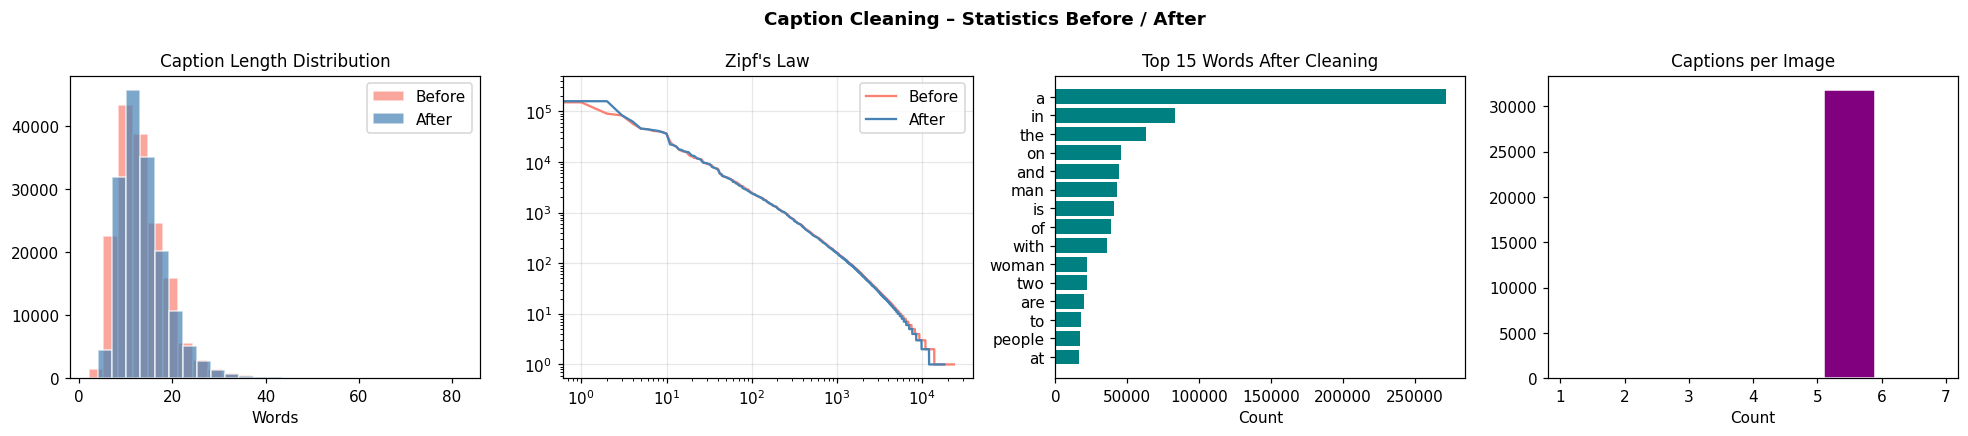

In [17]:
# ─── BƯỚC 1: THỐNG KÊ TRƯỚC KHI CLEAN ────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  CAPTION CLEANING")
print(SEP)

all_words_before = Counter()
all_len_before   = []
for caps in all_descriptions.values():
    for cap in caps:
        toks = cap.split()
        all_words_before.update(toks)
        all_len_before.append(len(toks))

print(f"  BEFORE CLEANING:")
print(f"    Vocab size     : {len(all_words_before):,}")
print(f"    Total tokens   : {sum(all_words_before.values()):,}")
print(f"    Avg cap length : {np.mean(all_len_before):.2f} words")

# ─── BƯỚC 2: HÀM CLEAN ────────────────────────────────────────────────────────
def clean_caption(caption: str) -> str:
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s']", ' ', caption)
    tokens  = caption.split()
    tokens  = [t for t in tokens
               if len(t) >= 1 and not any(c.isdigit() for c in t)]
    return ' '.join(tokens)

# ─── BƯỚC 3: THỰC HIỆN CLEAN ─────────────────────────────────────────────────
clean_descriptions = {}
for img_id, caps in all_descriptions.items():
    cleaned = []
    for cap in caps:
        c = clean_caption(cap)
        if c:
            cleaned.append(f"startseq {c} endseq")
    if cleaned:
        clean_descriptions[img_id] = cleaned

# ─── BƯỚC 4: THỐNG KÊ SAU KHI CLEAN ──────────────────────────────────────────
all_words_after = Counter()
all_len_after   = []
for caps in clean_descriptions.values():
    for cap in caps:
        toks = cap.split()
        all_words_after.update(toks)
        all_len_after.append(len(toks))

real_vocab_after = {w for w in all_words_after if w not in ('startseq', 'endseq')}
print(f"\n  AFTER CLEANING:")
print(f"    Vocab size     : {len(real_vocab_after):,}  (giảm {len(all_words_before)-len(real_vocab_after):,})")
print(f"    Total tokens   : {sum(all_words_after.values()):,}")
print(f"    Avg cap length : {np.mean(all_len_after):.2f} words (incl. startseq/endseq)")

# ─── BƯỚC 5: TRỰC QUAN (4 BIỂU ĐỒ) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Caption Cleaning – Statistics Before / After', fontweight='bold')

axes[0].hist(all_len_before, bins=25, color='salmon',    edgecolor='white', alpha=0.7, label='Before')
axes[0].hist(all_len_after,  bins=25, color='steelblue', edgecolor='white', alpha=0.7, label='After')
axes[0].set_title('Caption Length Distribution'); axes[0].set_xlabel('Words'); axes[0].legend()

freq_before = sorted(all_words_before.values(), reverse=True)
freq_after  = sorted(all_words_after.values(),  reverse=True)
axes[1].loglog(freq_before, color='salmon',    label='Before')
axes[1].loglog(freq_after,  color='steelblue', label='After')
axes[1].set_title("Zipf's Law"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

top15 = [(w,c) for w,c in all_words_after.most_common(25)
         if w not in ('startseq','endseq')][:15]
axes[2].barh([w for w,_ in top15][::-1], [c for _,c in top15][::-1], color='teal')
axes[2].set_title('Top 15 Words After Cleaning'); axes[2].set_xlabel('Count')

lengths = [len(caps) for caps in clean_descriptions.values()]
axes[3].hist(lengths, bins=range(1, 8), color='purple', edgecolor='white', rwidth=0.8)
axes[3].set_title('Captions per Image'); axes[3].set_xlabel('Count')

plt.tight_layout(); plt.show()


## Cell 10: Tokenization và GloVe Embeddings

**Mục đích:**
- Xây dựng từ điển (word→index) từ tập train
- Load GloVe pre-trained embeddings 300d
- Tạo embedding matrix khởi tạo cho model

**Lưu ý:** Tokenizer dùng chung với VGG16 version (nếu file đã tồn tại).
Điều này đảm bảo cùng vocabulary, giúp so sánh kết quả giữa hai model công bằng.


In [18]:
# ─── BƯỚC 1: TẢI SPLITS ──────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TOKENIZATION & GLOVE EMBEDDINGS")
print(SEP)

assert SPLITS_PATH.exists(), f"❌ Splits not found: {SPLITS_PATH} – re-run cell 8"
with open(SPLITS_PATH) as f:
    splits = json.load(f)
train_ids = set(splits['train'])
dev_ids   = set(splits['val'])
test_ids  = set(splits['test'])
print(f"  Train: {len(train_ids):,} | Dev: {len(dev_ids):,} | Test: {len(test_ids):,}")

# ─── BƯỚC 2: LỌC DESCRIPTIONS THEO SPLIT ────────────────────────────────────
def load_split_descriptions(split_ids: set) -> Dict[str, List[str]]:
    return {img_id: caps for img_id, caps in clean_descriptions.items()
            if img_id in split_ids}

train_desc = load_split_descriptions(train_ids)
dev_desc   = load_split_descriptions(dev_ids)
test_desc  = load_split_descriptions(test_ids)
print(f"\n  Train: {len(train_desc):,} imgs, {sum(len(v) for v in train_desc.values()):,} caps")
print(f"  Dev  : {len(dev_desc):,} imgs,  {sum(len(v) for v in dev_desc.values()):,} caps")
print(f"  Test : {len(test_desc):,} imgs,  {sum(len(v) for v in test_desc.values()):,} caps")

# ─── BƯỚC 3: XÂY DỰNG TOKENIZER ─────────────────────────────────────────────
if TOKENIZER_PATH.exists() and not FORCE_RETRAIN:
    with open(TOKENIZER_PATH, 'rb') as f:
        tok = pickle.load(f)
    word2idx        = tok['word2idx']
    idx2word        = tok['idx2word']
    vocab_size_actual = tok['vocab_size']
    MAX_LEN         = tok['max_len']
    EMBED_DIM       = tok['embed_dim']
    print(f"\n  ✅ Tokenizer loaded: vocab={vocab_size_actual:,}, max_len={MAX_LEN}, embed={EMBED_DIM}d")
else:
    print("\n  Building vocabulary from training set...")
    train_word_freq = Counter()
    for caps in train_desc.values():
        for cap in caps:
            train_word_freq.update(cap.split())

    SPECIAL = ['<pad>', '<unk>', 'startseq', 'endseq']
    common_words = [w for w, _ in train_word_freq.most_common() if w not in SPECIAL]
    vocab_words  = SPECIAL + common_words[:VOCAB_SIZE - len(SPECIAL)]
    word2idx = {w: i for i, w in enumerate(vocab_words)}
    idx2word = {i: w for i, w in enumerate(vocab_words)}
    vocab_size_actual = len(vocab_words)

    all_train_lengths = [len(cap.split()) for caps in train_desc.values() for cap in caps]
    MAX_LEN = min(max(all_train_lengths) + 1, MAX_LENGTH)
    print(f"  Vocab kept : {vocab_size_actual:,}")
    print(f"  MAX_LEN    : {MAX_LEN}")

# ─── BƯỚC 4: SPECIAL TOKEN IDs ────────────────────────────────────────────────
START_ID = word2idx['startseq']
END_ID   = word2idx['endseq']
PAD_ID   = word2idx['<pad>']
UNK_ID   = word2idx['<unk>']
print(f"\n  Special IDs: pad={PAD_ID}, unk={UNK_ID}, start={START_ID}, end={END_ID}")

# ─── BƯỚC 5: LOAD GLOVE ──────────────────────────────────────────────────────
print(f"\n  Searching for GloVe file...")
glove_path = None
for p in GLOVE_SEARCH_PATHS:
    if p.exists():
        glove_path = p
        break

embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size_actual, EMBED_DIM)).astype('float32')
embedding_matrix[PAD_ID] = 0.0

if glove_path:
    print(f"  Found GloVe: {glove_path}  ({glove_path.stat().st_size//1024//1024} MB)")
    glove_dim  = int(str(glove_path).split('.')[-2].replace('d',''))
    EMBED_DIM  = glove_dim
    embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size_actual, EMBED_DIM)).astype('float32')
    embedding_matrix[PAD_ID] = 0.0

    glove_vecs = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in tqdm(f, desc='Loading GloVe', unit='lines'):
            parts = line.split()
            glove_vecs[parts[0]] = np.array(parts[1:], dtype='float32')

    hits = 0
    for word, idx in word2idx.items():
        if word in glove_vecs:
            embedding_matrix[idx] = glove_vecs[word]
            hits += 1
    coverage = hits / vocab_size_actual * 100
    print(f"  GloVe coverage : {hits:,}/{vocab_size_actual:,} ({coverage:.1f}%)")
    del glove_vecs; gc.collect()
else:
    print("  ⚠️  GloVe not found — random embeddings")

# Lưu tokenizer (nếu chưa có)
if not TOKENIZER_PATH.exists() or FORCE_RETRAIN:
    tok_data = {'word2idx': word2idx, 'idx2word': idx2word,
                'vocab_size': vocab_size_actual, 'max_len': MAX_LEN, 'embed_dim': EMBED_DIM}
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tok_data, f)
    print(f"  ✅ Tokenizer saved → {TOKENIZER_PATH}")

print(f"\n  Embedding matrix : {embedding_matrix.shape}  ({embedding_matrix.nbytes//1024//1024} MB)")
print(f"  EMBED_DIM used   : {EMBED_DIM}d")


  TOKENIZATION & GLOVE EMBEDDINGS
  Train: 29,769 | Dev: 1,014 | Test: 1,000

  Train: 29,769 imgs, 148,844 caps
  Dev  : 1,014 imgs,  5,070 caps
  Test : 1,000 imgs,  5,000 caps

  ✅ Tokenizer loaded: vocab=10,000, max_len=35, embed=300d

  Special IDs: pad=0, unk=1, start=2, end=3

  Searching for GloVe file...
  Found GloVe: /Applications/Python_AI/Neural_Image_Caption_Generation/glove.6B.300d.txt  (989 MB)


Loading GloVe: 400000lines [00:07, 50473.06lines/s]


  GloVe coverage : 9,922/10,000 (99.2%)

  Embedding matrix : (10000, 300)  (11 MB)
  EMBED_DIM used   : 300d


## Cell 11: Tạo Training Samples (PyTorch Dataset + DataLoader)

**Kỹ thuật Teacher Forcing:**
```
Caption:  startseq  a   dog  runs  on  grass  endseq
Input  :  startseq  a   dog  runs  on  grass          ← X_caption
Target :            a   dog  runs  on  grass  endseq  ← Y_target
```

`CaptionDataset` dùng **lazy loading**: mỗi `__getitem__` đọc file `{img_id}.npy` từ `FEAT_NPY_DIR` — không load toàn bộ features vào RAM.


In [19]:
# ─── BƯỚC 1: GIẢI THÍCH CẤU TRÚC ────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PYTORCH DATASET + DATALOADER (Lazy Loading)")
print(SEP)

ex_cap = "startseq a dog runs on grass endseq"
ex_ids = [word2idx.get(w, UNK_ID) for w in ex_cap.split()]
print(f"  Teacher Forcing example:")
print(f"    Caption : {ex_cap}")
print(f"    Input   : {[idx2word.get(i,'?') for i in ex_ids[:-1]]}")
print(f"    Target  : {[idx2word.get(i,'?') for i in ex_ids[1:]]}")

# ─── BƯỚC 2: DATASET CLASS (LAZY LOADING) ────────────────────────────────────
class CaptionDataset(Dataset):
    """PyTorch Dataset với Lazy Loading — đọc .npy từ disk theo từng batch.
    Tiết kiệm ~5-6 GB RAM so với load toàn bộ features vào dict.
    """

    def __init__(self,
                 descriptions : Dict[str, List[str]],
                 feat_dir     : Path,
                 word2idx     : Dict[str, int],
                 max_len      : int,
                 valid_ids    : set = None):
        self.feat_dir = feat_dir
        self.max_len  = max_len
        unk = word2idx.get('<unk>', 1)
        pad = word2idx.get('<pad>', 0)
        self.samples: List[Tuple[str, np.ndarray, np.ndarray]] = []
        skipped = 0

        for img_id, caps in descriptions.items():
            # Chỉ thêm nếu file .npy tồn tại
            if not (feat_dir / f'{img_id}.npy').exists():
                skipped += 1
                continue
            if valid_ids is not None and img_id not in valid_ids:
                continue
            for cap in caps:
                ids = [word2idx.get(w, unk) for w in cap.split()]
                ids = ids[:max_len]
                ids += [pad] * (max_len - len(ids))
                inp = np.array(ids[:-1], dtype=np.int64)
                tgt = np.array(ids[1:],  dtype=np.int64)
                self.samples.append((img_id, inp, tgt))

        if skipped:
            print(f"  ⚠️  {skipped} images skipped (no .npy file)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, inp, tgt = self.samples[idx]
        # Load từ disk — chỉ 1 file ~200 KB, rất nhanh trên SSD
        feat = np.load(self.feat_dir / f'{img_id}.npy').astype('float32')
        return (torch.FloatTensor(feat),
                torch.LongTensor(inp),
                torch.LongTensor(tgt))

# ─── BƯỚC 3: TẠO DATASETS (không cần feat dict trong RAM) ────────────────────
print("\n  Creating datasets (lazy loading mode)...")

train_dataset = CaptionDataset(train_desc, FEAT_NPY_DIR, word2idx, MAX_LEN, valid_ids=train_ids)
dev_dataset   = CaptionDataset(dev_desc,   FEAT_NPY_DIR, word2idx, MAX_LEN, valid_ids=dev_ids)
test_dataset  = CaptionDataset(test_desc,  FEAT_NPY_DIR, word2idx, MAX_LEN, valid_ids=test_ids)

print(f"  Train samples : {len(train_dataset):,}")
print(f"  Dev samples   : {len(dev_dataset):,}")
print(f"  Test samples  : {len(test_dataset):,}")

# ─── BƯỚC 4: DATALOADERS ─────────────────────────────────────────────────────
# num_workers=0 trên macOS/MPS để tránh lỗi multiprocessing
# Lazy loading đã tiết kiệm RAM, không cần num_workers cao
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0,
                          pin_memory=False)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"\n  Train loader : {len(train_loader):,} batches × {BATCH_SIZE}")
print(f"  Dev loader   : {len(dev_loader):,} batches")
print(f"  Test loader  : {len(test_loader):,} batches")

# ─── BƯỚC 5: VERIFY ──────────────────────────────────────────────────────────
feat_b, inp_b, tgt_b = next(iter(train_loader))
print(f"\n  Batch shapes (lazy loaded):")
print(f"    features : {tuple(feat_b.shape)}  ← (B, 49, 2048)")
print(f"    input    : {tuple(inp_b.shape)}")
print(f"    target   : {tuple(tgt_b.shape)}")
del feat_b, inp_b, tgt_b; gc.collect()
print(f"  ✅ Lazy loading OK — features NOT in RAM, read from disk per batch")


  PYTORCH DATASET + DATALOADER
  Teacher Forcing example:
    Caption : startseq a dog runs on grass endseq
    Input   : ['startseq', 'a', 'dog', 'runs', 'on', 'grass']
    Target  : ['a', 'dog', 'runs', 'on', 'grass', 'endseq']

  Creating datasets...
  ✅ features_conv released from RAM — keeping only train/val features
  ⚠️  1000 images skipped (no features)
  Train samples : 148,844
  Dev samples   : 5,070
  Test samples  : 0

  Train loader : 4,652 batches × 32
  Dev loader   : 159 batches
  Test loader  : 0 batches

  Batch shapes (ResNet-101):
    features : (32, 49, 2048)  ← (B, 49, 2048)
    input    : (32, 34)   ← (B, T-1)
    target   : (32, 34)   ← (B, T-1)


## Cell 12: Xây dựng Kiến trúc Model

**Kiến trúc Encoder-Decoder với Bahdanau Attention:**

```
ResNet-101 features (B, 49, 2048)
       │
       ├──► Init hidden: Linear(2048→512) tanh ──► h₀, c₀
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│  DECODER LSTM (T bước)                                  │
│                                                         │
│  embed_t = Embedding[token_t]     (B, 300)              │
│                                                         │
│  context, αt = BahdanauAttention(hₜ₋₁, features)       │
│      ├ W_h(hₜ₋₁) + W_f(features) → energy (B, 49, 1)   │
│      └ softmax(energy) × features → context (B, 2048)   │
│                                                         │
│  input_t = concat(embed_t, context)  (B, 300+2048=2348) │
│  hₜ, cₜ  = LSTMCell(input_t, hₜ₋₁, cₜ₋₁)              │
│  logit_t  = Linear(512 → vocab_size)                    │
└─────────────────────────────────────────────────────────┘
       │
       ▼
 logits (B, T, vocab_size)
```

**So sánh với VGG16 version:**

| | VGG16 version | ResNet-101 version |
|--|---------------|-------------------|
| Feature size | 512 | **2048** |
| LSTM input | 300+512=812 | **300+2048=2348** |
| Init hidden | Linear(512→512) | **Linear(2048→512)** |
| Attention W_f | Linear(512→512) | **Linear(2048→512)** |
| fc_out | Linear(512→vocab) | Linear(512→vocab) |


In [20]:
# ─── ĐỊNH NGHĨA CÁC CLASS ────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  MODEL ARCHITECTURE – ResNet-101 + Bahdanau Attention")
print(SEP)

class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) Attention.

    Score(h, f_i) = V · tanh(W_h·h + W_f·f_i)
    α = softmax(scores)
    context = Σ αᵢ · fᵢ

    Args:
        hidden_size  : LSTM hidden size (512)
        feature_size : backbone output channels (2048 for ResNet-101)
    """
    def __init__(self, hidden_size: int, feature_size: int):
        super().__init__()
        self.W_h = nn.Linear(hidden_size,  hidden_size, bias=False)
        self.W_f = nn.Linear(feature_size, hidden_size, bias=False)
        self.V   = nn.Linear(hidden_size,  1,           bias=False)

    def forward(self, hidden: torch.Tensor, features: torch.Tensor):
        """
        hidden   : (B, hidden_size)
        features : (B, num_regions, feature_size)
        returns  : context (B, feature_size), weights (B, num_regions)
        """
        h_exp   = self.W_h(hidden).unsqueeze(1)       # (B, 1, H)
        f_proj  = self.W_f(features)                   # (B, 49, H)
        energy  = self.V(torch.tanh(h_exp + f_proj))  # (B, 49, 1)
        weights = torch.softmax(energy, dim=1)         # (B, 49, 1)
        context = (weights * features).sum(dim=1)      # (B, 2048)
        return context, weights.squeeze(-1)            # (B,2048), (B,49)


class CaptionDecoder(nn.Module):
    """LSTM Decoder with Bahdanau Attention for Image Captioning.

    Supports ResNet-101 features (feature_size=2048, num_regions=49).
    """

    def __init__(self,
                 vocab_size       : int,
                 embed_dim        : int,
                 hidden_size      : int,
                 feature_size     : int   = 2048,
                 dropout          : float = 0.5,
                 embedding_matrix : Optional[np.ndarray] = None,
                 embed_trainable  : bool  = True):
        super().__init__()
        self.hidden_size  = hidden_size
        self.feature_size = feature_size

        # Embedding layer (GloVe khởi tạo)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.FloatTensor(embedding_matrix),
                requires_grad=embed_trainable
            )

        self.attention = BahdanauAttention(hidden_size, feature_size)

        # LSTM input = embed_dim + feature_size (context)
        # VGG16: 300+512=812   |   ResNet-101: 300+2048=2348
        self.lstm    = nn.LSTM(embed_dim + feature_size, hidden_size, batch_first=True)

        # Khởi tạo h₀, c₀ từ mean image features
        self.init_h  = nn.Linear(feature_size, hidden_size)
        self.init_c  = nn.Linear(feature_size, hidden_size)

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_size, vocab_size)

    def _init_hidden(self, features: torch.Tensor):
        """features: (B, 49, 2048) → h0, c0: (1, B, 512)"""
        mean_feat = features.mean(dim=1)                         # (B, 2048)
        h = torch.tanh(self.init_h(mean_feat)).unsqueeze(0)     # (1, B, 512)
        c = torch.tanh(self.init_c(mean_feat)).unsqueeze(0)     # (1, B, 512)
        return h, c

    def forward(self, features: torch.Tensor, captions: torch.Tensor):
        """
        features : (B, 49, 2048)
        captions : (B, T)  — teacher-forced input (startseq...last_word)
        returns  : logits (B, T, vocab_size)
        """
        emb  = self.dropout(self.embedding(captions))   # (B, T, 300)
        h, c = self._init_hidden(features)              # (1,B,512), (1,B,512)
        logits = []

        for t in range(captions.size(1)):
            h_t            = h.squeeze(0)               # (B, 512)
            context, _     = self.attention(h_t, features)   # (B, 2048)
            lstm_in        = torch.cat([emb[:, t, :], context], dim=1).unsqueeze(1)  # (B,1,2348)
            _, (h, c)      = self.lstm(lstm_in, (h, c))
            out            = self.fc_out(self.dropout(h.squeeze(0)))  # (B, vocab)
            logits.append(out.unsqueeze(1))             # (B, 1, vocab)

        return torch.cat(logits, dim=1)                 # (B, T, vocab)

    @torch.no_grad()
    def generate_beam(self,
                      features   : torch.Tensor,
                      beam_width : int = 5,
                      max_len    : int = 35) -> str:
        """Beam Search inference.

        features : (1, 49, 2048)
        returns  : caption string (without startseq/endseq)
        """
        self.eval()
        h, c   = self._init_hidden(features)            # (1,1,512)
        device = features.device

        # Beam: list of (score, token_ids, h, c)
        beams = [(0.0, [START_ID], h, c)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for score, seq, h_b, c_b in beams:
                if seq[-1] == END_ID:
                    completed.append((score, seq))
                    continue
                tok   = torch.tensor([[seq[-1]]], device=device)
                emb_t = self.dropout(self.embedding(tok))       # (1,1,300)
                h_t   = h_b.squeeze(0)                          # (1,512)
                ctx, _= self.attention(h_t, features)           # (1,2048)
                inp   = torch.cat([emb_t.squeeze(1), ctx], dim=1).unsqueeze(1)
                _, (h_new, c_new) = self.lstm(inp, (h_b, c_b))
                out   = self.fc_out(h_new.squeeze(0))           # (1, vocab)
                log_p = torch.log_softmax(out, dim=-1)
                topk  = log_p.topk(beam_width, dim=-1)
                for k in range(beam_width):
                    tok_id   = topk.indices[0, k].item()
                    tok_score = topk.values[0, k].item()
                    candidates.append((score + tok_score,
                                       seq + [tok_id],
                                       h_new, c_new))
            if not candidates:
                break
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]

        completed += [(s, seq) for s, seq, _, _ in beams]
        best_seq = max(completed, key=lambda x: x[0])[1]
        words = [idx2word.get(t, '') for t in best_seq
                 if t not in (START_ID, END_ID, PAD_ID)]
        return ' '.join(words)


# ─── KHỞI TẠO MODEL ──────────────────────────────────────────────────────────
model = CaptionDecoder(
    vocab_size       = vocab_size_actual,
    embed_dim        = EMBED_DIM,
    hidden_size      = HIDDEN_SIZE,
    feature_size     = FEATURE_SIZE,          # ← 2048
    dropout          = DROPOUT,
    embedding_matrix = embedding_matrix,
    embed_trainable  = EMBED_TRAINABLE,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Model        : CaptionDecoder (LSTM-{HIDDEN_SIZE} + BahdanauAttention)")
print(f"  feature_size : {FEATURE_SIZE}  (ResNet-101)")
print(f"  LSTM input   : {EMBED_DIM}+{FEATURE_SIZE}={EMBED_DIM+FEATURE_SIZE}  (embed+context)")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")

# Lưu model config
arch_cfg = {
    'backbone'    : 'ResNet-101',
    'feature_size': FEATURE_SIZE,
    'num_regions' : NUM_REGIONS,
    'vocab_size'  : vocab_size_actual,
    'embed_dim'   : EMBED_DIM,
    'hidden_size' : HIDDEN_SIZE,
    'dropout'     : DROPOUT,
    'total_params': total_params,
}
with open(MODEL_DIR / 'model_architecture_resnet101.json', 'w') as f:
    json.dump(arch_cfg, f, indent=2)
print(f"  ✅ Architecture saved → {MODEL_DIR / 'model_architecture_resnet101.json'}")


  MODEL ARCHITECTURE – ResNet-101 + Bahdanau Attention
  Model        : CaptionDecoder (LSTM-512 + BahdanauAttention)
  feature_size : 2048  (ResNet-101)
  LSTM input   : 300+2048=2348  (embed+context)
  Total params     : 17,400,784
  Trainable params : 17,400,784
  ✅ Architecture saved → /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/models/model_architecture_resnet101.json


## Cell 13: Huấn luyện Model

**Cấu hình training:**

| Thành phần | Cấu hình |
|---|---|
| Loss | `CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)` |
| Optimizer | `AdamW(lr=1e-4, weight_decay=1e-4)` |
| LR Scheduler | `ReduceLROnPlateau(factor=0.5, patience=3)` |
| Gradient Clip | `clip_grad_norm_(max_norm=5.0)` |
| Early Stopping | patience=7 |
| Best Model | Lưu khi `val_loss` thấp nhất |


  MODEL TRAINING – ResNet-101
  Device     : Apple MPS (GPU) ✅
  Loss       : CrossEntropyLoss(ignore=0, smooth=0.1)
  Optimizer  : AdamW(lr=0.0001, wd=0.0001)
  Scheduler  : ReduceLROnPlateau(factor=0.5, patience=3)
  Grad clip  : 5.0
  Epochs     : 10  (early stop patience=3)
  Steps/epoch: 4,652

  Starting training...

    [4650/4652] loss 4.6621 | acc 31.9%
  Epoch  1/10 | train_loss=4.6620 acc=31.9% | val_loss=4.3112 acc=35.0% | lr=1.0e-04 | 1203s
  ✅ Best model saved (val_loss=4.3112)
    [4650/4652] loss 4.3483 | acc 34.7%
  Epoch  2/10 | train_loss=4.3482 acc=34.7% | val_loss=4.1331 acc=36.8% | lr=1.0e-04 | 1201s
  ✅ Best model saved (val_loss=4.1331)
    [4650/4652] loss 4.1835 | acc 36.5%
  Epoch  3/10 | train_loss=4.1834 acc=36.5% | val_loss=4.0392 acc=37.8% | lr=1.0e-04 | 1205s
  ✅ Best model saved (val_loss=4.0392)
    [4650/4652] loss 4.0724 | acc 37.9%
  Epoch  4/10 | train_loss=4.0723 acc=37.9% | val_loss=3.9819 acc=38.5% | lr=1.0e-04 | 1212s
  ✅ Best model saved (val_

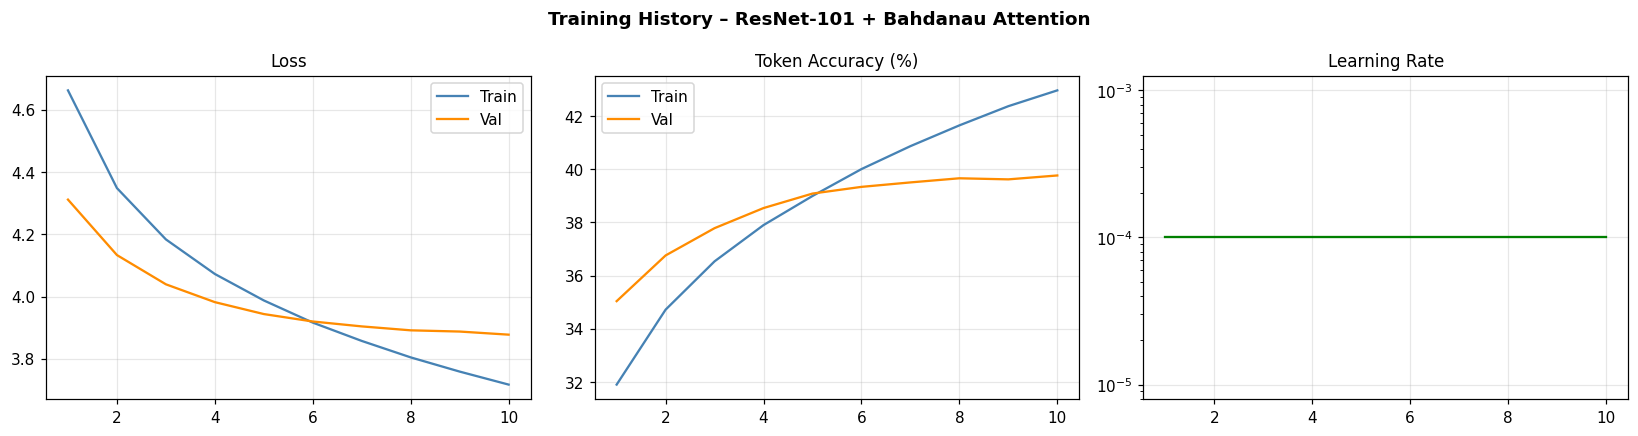

In [17]:
# ─── CẤU HÌNH TRAINING ────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  MODEL TRAINING – ResNet-101")
print(SEP)

if device.type == 'mps':
    device_label = 'Apple MPS (GPU) ✅'
elif device.type == 'cuda':
    device_label = f'CUDA GPU — {torch.cuda.get_device_name(0)} ✅'
else:
    device_label = 'CPU ❌'
print(f"  Device     : {device_label}")

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

print(f"  Loss       : CrossEntropyLoss(ignore={PAD_ID}, smooth={LABEL_SMOOTHING})")
print(f"  Optimizer  : AdamW(lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Scheduler  : ReduceLROnPlateau(factor={LR_FACTOR}, patience={LR_PATIENCE})")
print(f"  Grad clip  : {GRAD_CLIP}")
print(f"  Epochs     : {EPOCHS}  (early stop patience={EARLY_STOP_PATIENCE})")
print(f"  Steps/epoch: {len(train_loader):,}")

# ─── TRAINING LOOP ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
patience_ctr  = 0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = total_correct = total_tokens = total_n = 0
    n_steps    = len(loader)
    log_every  = max(1, n_steps // 5)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for step, (feat, inp, tgt) in enumerate(loader, 1):
            feat = feat.to(device)
            inp  = inp.to(device)
            tgt  = tgt.to(device)

            logits = model(feat, inp)                   # (B, T, V)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B*T, V), tgt.reshape(B*T))

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            with torch.no_grad():
                pred = logits.argmax(dim=-1)
                mask = tgt != PAD_ID
                total_correct += ((pred == tgt) & mask).sum().item()
                total_tokens  += mask.sum().item()

            total_loss += loss.item() * B
            total_n    += B

            if train and step % log_every == 0:
                print(f"\r    [{step:>4}/{n_steps}] loss {total_loss/total_n:.4f} | "
                      f"acc {total_correct/max(total_tokens,1)*100:.1f}%", end='', flush=True)

    return total_loss / total_n, total_correct / max(total_tokens, 1) * 100

if MODEL_PATH.exists() and not FORCE_RETRAIN:
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    print(f"  ✅ Checkpoint loaded — skipping training (FORCE_RETRAIN=False)")
    print(f"     epoch={checkpoint.get('epoch','?')}, val_loss={checkpoint.get('val_loss','?'):.4f}")
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH) as _f:
            history = json.load(_f)
        print(f"  ✅ History loaded: {len(history.get('train_loss',[]))} epochs")
else:
    print(f"\n  Starting training...\n")
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        train_loss, train_acc = run_epoch(train_loader, train=True)
        val_loss,   val_acc   = run_epoch(dev_loader,   train=False)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        elapsed = time.time() - t0
        print(f"\n  Epoch {epoch:>2}/{EPOCHS} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.1f}% | "
              f"val_loss={val_loss:.4f} acc={val_acc:.1f}% | "
              f"lr={current_lr:.1e} | {elapsed:.0f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'val_loss'   : val_loss,
                'arch'       : {'backbone': 'ResNet-101', 'feature_size': FEATURE_SIZE,
                                'hidden_size': HIDDEN_SIZE, 'embed_dim': EMBED_DIM},
            }, MODEL_PATH)
            print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")
        else:
            patience_ctr += 1
            print(f"  ⏳ No improve — patience {patience_ctr}/{EARLY_STOP_PATIENCE}")
            if patience_ctr >= EARLY_STOP_PATIENCE:
                print(f"  🛑 Early stopping at epoch {epoch}")
                break

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"  ✅ History saved → {HISTORY_PATH}")

# ─── PLOT TRAINING HISTORY ────────────────────────────────────────────────────
if history['train_loss']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Training History – ResNet-101 + Bahdanau Attention', fontweight='bold')
    epochs_ran = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='darkorange')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_ran, history['train_acc'], label='Train', color='steelblue')
    axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   color='darkorange')
    axes[1].set_title('Token Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_ran, history['lr'], color='green')
    axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


## Cell 14: Đánh giá Model với BLEU Score

**BLEU Score (Bilingual Evaluation Understudy):**
- BLEU-1: unigram  |  BLEU-2: bigram  |  BLEU-3: trigram  |  BLEU-4: 4-gram
- **BLEU-4 là chỉ số chính** trong các bài báo Image Captioning

**So sánh công bằng với VGG16 version:**
- Cùng tập test (từ `flickr30k_splits.json`)
- Cùng vocabulary (từ `tokenizer_flickr30k.pkl`)
- Cùng cleaning logic

**Mục tiêu:** BLEU-4 > 0.22  (ResNet-101 có features phong phú hơn VGG16)


  BLEU SCORE EVALUATION – ResNet-101
  ✅ Best model loaded: epoch=10, val_loss=3.8775

  Generating captions for 1,000 test images (beam_width=5)...


Generating: 100%|██████████| 1000/1000 [05:20<00:00,  3.12it/s]



  ╔═════════════════════════════════════════════╗
  ║  EVALUATION RESULTS – ResNet-101             ║
  ╠═════════════════════════════════════════════╣
  ║  BLEU-1 : 0.6808                               ║
  ║  BLEU-2 : 0.4948                               ║
  ║  BLEU-3 : 0.3502                               ║
  ║  BLEU-4 : 0.2484   ← main metric               ║
  ╠═════════════════════════════════════════════╣
  ║  VGG16 version target  : BLEU-4 > 0.20      ║
  ║  ResNet-101 target     : BLEU-4 > 0.22      ║
  ╚═════════════════════════════════════════════╝

  BLEU-4 per image:
    Mean   : 0.2166
    Median : 0.1395
    P25/P75: 0.0648 / 0.3342

  ✅ Saved to /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/models/evaluation_results_resnet101.json


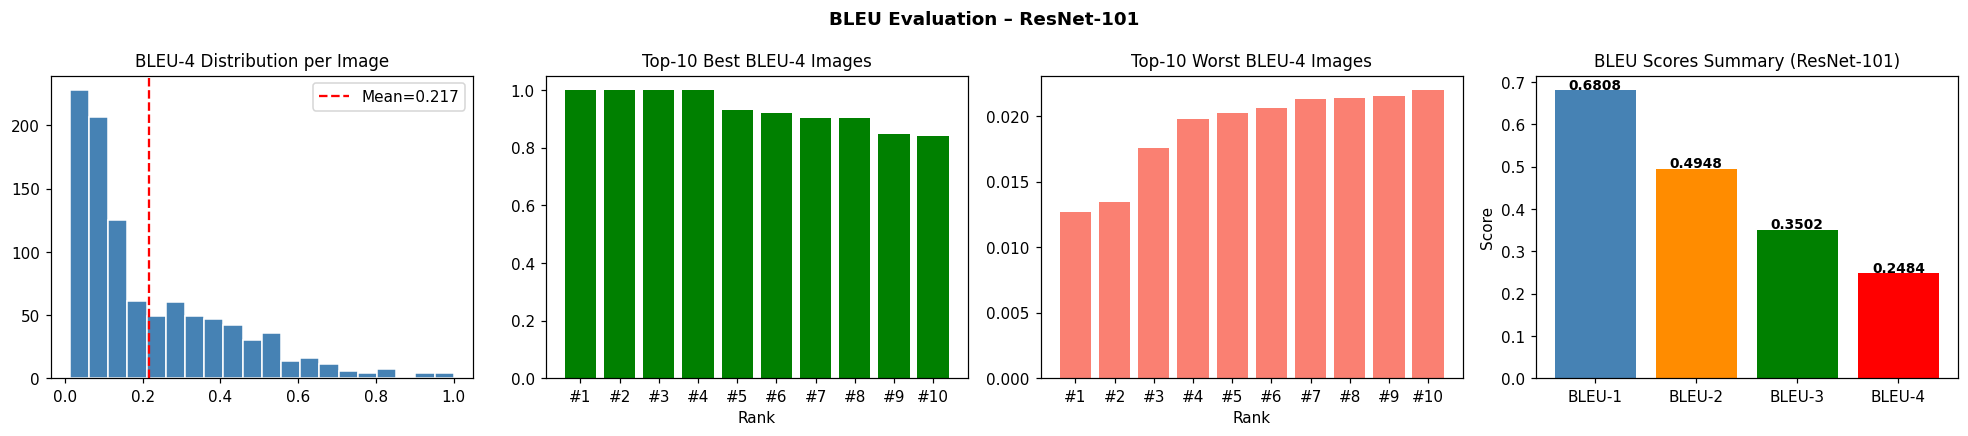

In [19]:
# ─── LOAD BEST MODEL ─────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  BLEU SCORE EVALUATION – ResNet-101")
print(SEP)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    print(f"  ✅ Best model loaded: epoch={checkpoint.get('epoch','?')}, "
          f"val_loss={checkpoint.get('val_loss','?'):.4f}")
else:
    print("  ⚠️  Checkpoint not found — using current model weights.")

model.eval()

# ─── SINH CAPTIONS CHO TẬP TEST ──────────────────────────────────────────────
print(f"\n  Generating captions for {len(test_desc):,} test images (beam_width={BEAM_WIDTH})...")
smooth_fn = SmoothingFunction().method1

actual_refs   = []
predicted     = []
per_img_bleu4 = []

with torch.no_grad():
    for img_id, refs in tqdm(test_desc.items(), desc='Generating'):
        feat_path = FEAT_NPY_DIR / f'{img_id}.npy'
        if not feat_path.exists():
            continue
        feat    = torch.FloatTensor(
            np.load(feat_path).astype('float32')
        ).unsqueeze(0).to(device)
        caption = model.generate_beam(feat, beam_width=BEAM_WIDTH, max_len=MAX_LEN)
        pred_toks = caption.split()

        ref_list = [[w for w in ref.split() if w not in ('startseq','endseq')]
                    for ref in refs]
        actual_refs.append(ref_list)
        predicted.append(pred_toks)

        b4 = sentence_bleu(ref_list, pred_toks,
                           weights=(0.25,0.25,0.25,0.25),
                           smoothing_function=smooth_fn)
        per_img_bleu4.append(b4)

# ─── TÍNH BLEU CORPUS ────────────────────────────────────────────────────────
bleu1 = corpus_bleu(actual_refs, predicted, weights=(1, 0, 0, 0))
bleu2 = corpus_bleu(actual_refs, predicted, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual_refs, predicted, weights=(1/3, 1/3, 1/3, 0))
bleu4 = corpus_bleu(actual_refs, predicted, weights=(0.25, 0.25, 0.25, 0.25))

print(f"\n  ╔{'═'*45}╗")
print(f"  ║  EVALUATION RESULTS – ResNet-101             ║")
print(f"  ╠{'═'*45}╣")
print(f"  ║  BLEU-1 : {bleu1:.4f}                               ║")
print(f"  ║  BLEU-2 : {bleu2:.4f}                               ║")
print(f"  ║  BLEU-3 : {bleu3:.4f}                               ║")
print(f"  ║  BLEU-4 : {bleu4:.4f}   ← main metric               ║")
print(f"  ╠{'═'*45}╣")
print(f"  ║  VGG16 version target  : BLEU-4 > 0.20      ║")
print(f"  ║  ResNet-101 target     : BLEU-4 > 0.22      ║")
print(f"  ╚{'═'*45}╝")

p25 = np.percentile(per_img_bleu4, 25)
p75 = np.percentile(per_img_bleu4, 75)
print(f"\n  BLEU-4 per image:")
print(f"    Mean   : {np.mean(per_img_bleu4):.4f}")
print(f"    Median : {np.median(per_img_bleu4):.4f}")
print(f"    P25/P75: {p25:.4f} / {p75:.4f}")

# ─── LƯU KẾT QUẢ ─────────────────────────────────────────────────────────────
eval_results = {
    "bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4,
    "n_images": len(actual_refs), "beam_width": BEAM_WIDTH
}
with open(MODEL_DIR / "evaluation_results_resnet101.json", "w") as f:
    json.dump(eval_results, f, indent=2)
print(f"\n  ✅ Saved to {MODEL_DIR / 'evaluation_results_resnet101.json'}")

# ─── TRỰC QUAN HOÁ (4 BIỂU ĐỒ) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('BLEU Evaluation – ResNet-101', fontweight='bold')

axes[0].hist(per_img_bleu4, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(per_img_bleu4), color='red', linestyle='--',
                label=f'Mean={np.mean(per_img_bleu4):.3f}')
axes[0].set_title('BLEU-4 Distribution per Image'); axes[0].legend()

# Top-10 best
best_idx = np.argsort(per_img_bleu4)[-10:][::-1]
axes[1].bar(range(10), [per_img_bleu4[i] for i in best_idx], color='green')
axes[1].set_title('Top-10 Best BLEU-4 Images'); axes[1].set_xlabel('Rank')
axes[1].set_xticks(range(10)); axes[1].set_xticklabels([f'#{i+1}' for i in range(10)])

# Bottom-10 worst
worst_idx = np.argsort(per_img_bleu4)[:10]
axes[2].bar(range(10), [per_img_bleu4[i] for i in worst_idx], color='salmon')
axes[2].set_title('Top-10 Worst BLEU-4 Images'); axes[2].set_xlabel('Rank')
axes[2].set_xticks(range(10)); axes[2].set_xticklabels([f'#{i+1}' for i in range(10)])

# BLEU summary bar chart
bleu_names = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
bleu_vals  = [bleu1, bleu2, bleu3, bleu4]
colors     = ['steelblue', 'darkorange', 'green', 'red']
axes[3].bar(bleu_names, bleu_vals, color=colors)
for i, (name, val) in enumerate(zip(bleu_names, bleu_vals)):
    axes[3].text(i, val + 0.003, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[3].set_title('BLEU Scores Summary (ResNet-101)'); axes[3].set_ylabel('Score')

plt.tight_layout(); plt.show()


## Cell 15: Demo – Sinh Caption cho Ảnh Mới

**Mục đích:**
- Demo sinh caption cho 4 ảnh test ngẫu nhiên
- Phân tích lỗi thường gặp (too short, repetition)
- Test với ảnh tùy chọn bên ngoài dataset
- So sánh BLEU-4 ResNet-101 vs VGG16 (biểu đồ)

**Kỳ vọng:**
- Caption mô tả đúng nội dung chính
- Câu hoàn chỉnh ngữ pháp (8–15 từ)
- BLEU-4 cao hơn VGG16 version


  DEMO – CAPTION GENERATION (ResNet-101)

  Generating captions for 4 random test images...

  [5949976408]
    Generated : a man doing a trick on a skateboard
    Ref[0]    : a guy on a skateboard does a trick on a ramp while others watch on the other side of the ramp

  [3480379024]
    Generated : a motorcyclist is riding a motorcycle
    Ref[0]    : two motorcycle racers are driving on a race course

  [4465359505]
    Generated : a man in a green shirt is looking at a table
    Ref[0]    : a barber with glasses is standing at his counter while another man is waiting in the barber chair

  [1663751778]
    Generated : a man is climbing on a rock
    Ref[0]    : a person wearing khaki pants climbing up the side of a rocky cliff


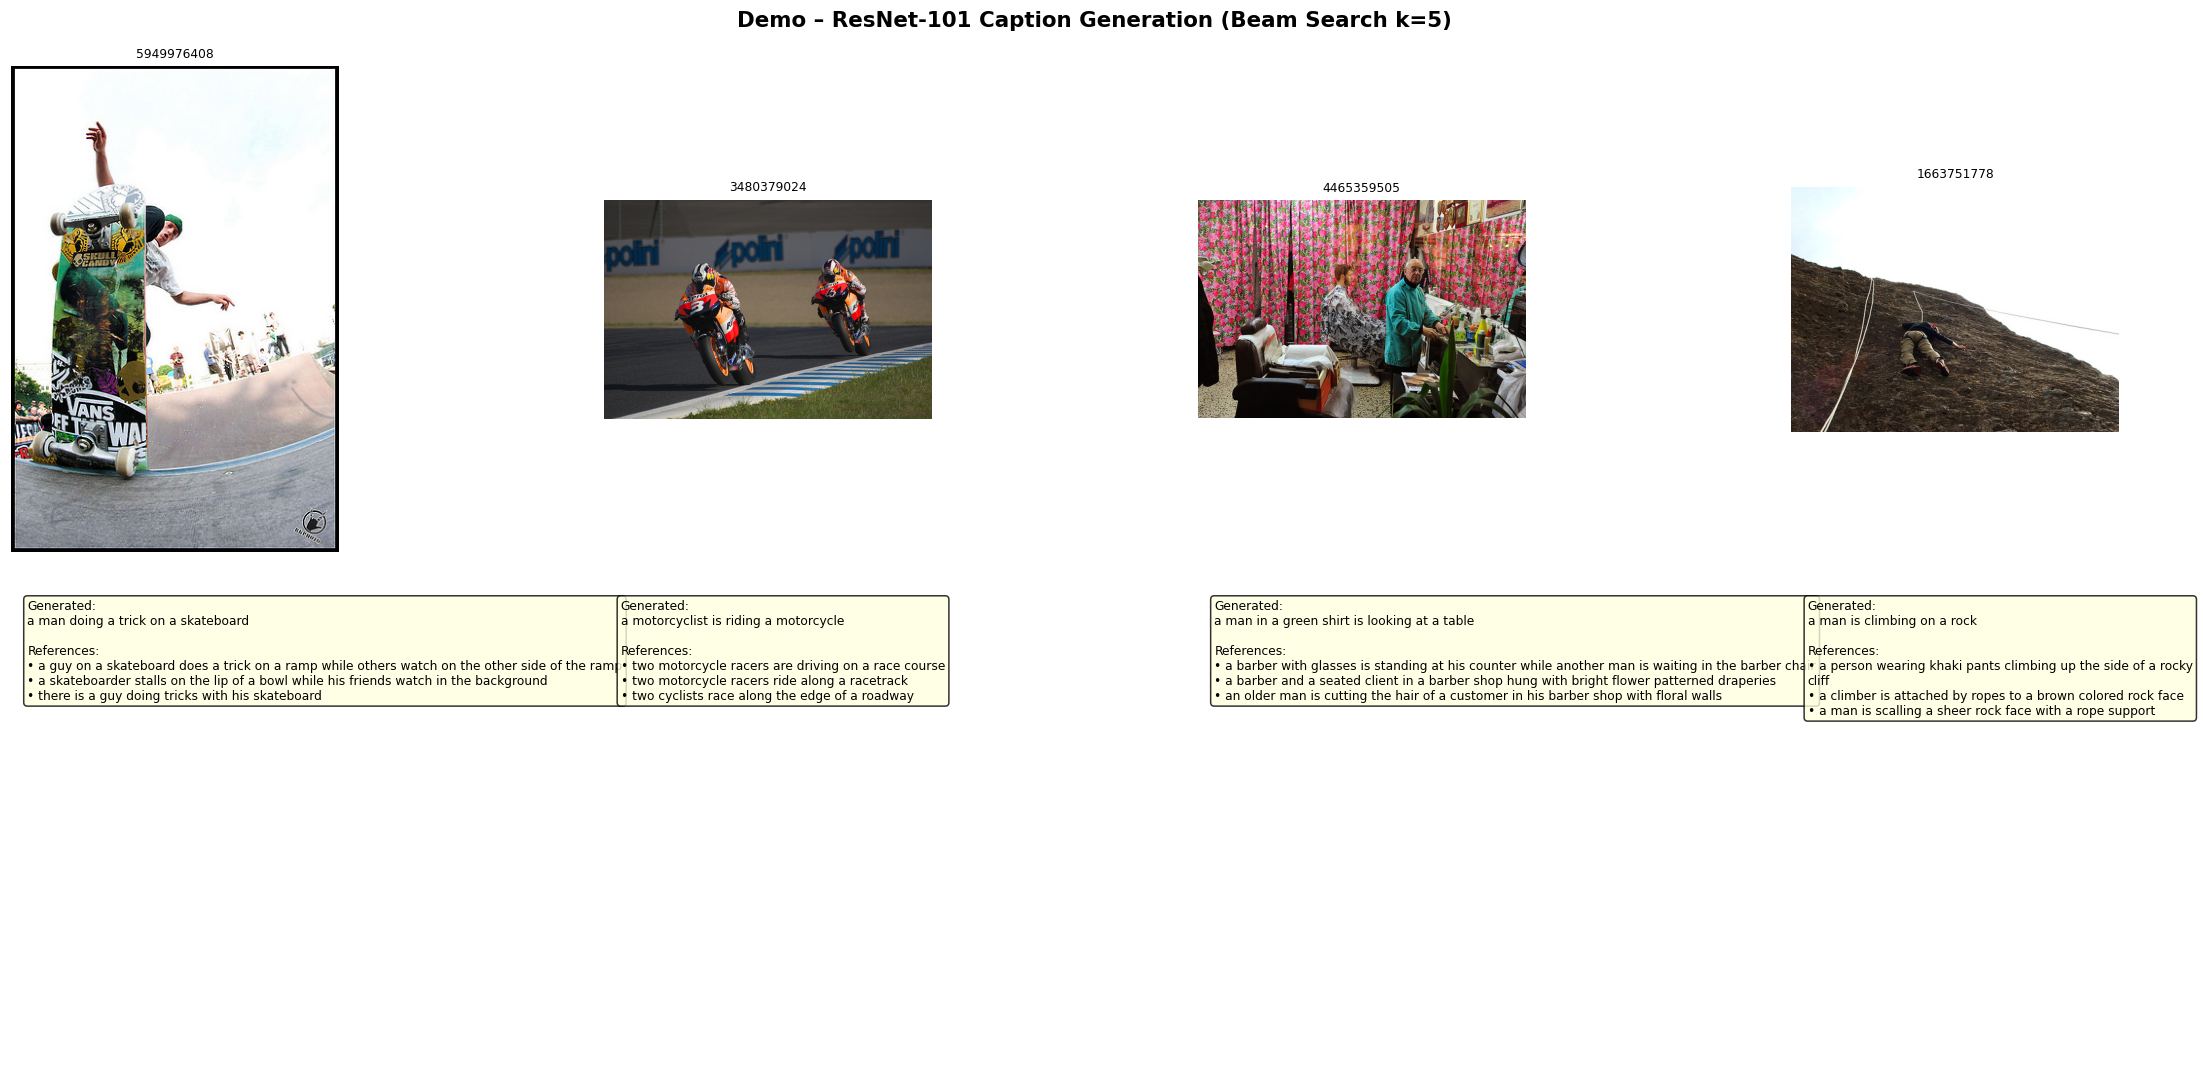


  ERROR ANALYSIS – 100 TEST IMAGES
  Analysis of 100 test images:
    too_short       : 0 (0%)
    repetition      : 3 (3%)
    good            : 97 (97%)

  CUSTOM IMAGE TEST (OPTIONAL)
  Chưa có ảnh tùy chọn.
  Set CUSTOM_IMAGE_PATH = '/path/to/image.jpg' để test.


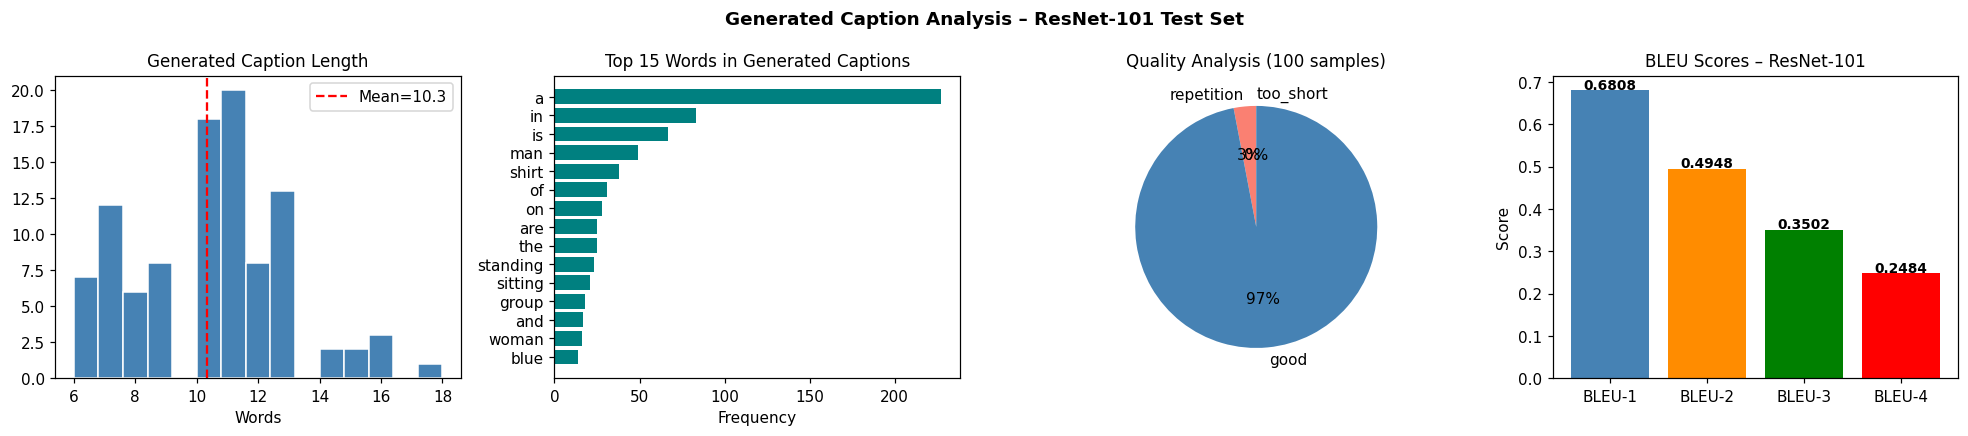


  COMPLETE – Neural Image Caption Generation (ResNet-101)
  Framework   : PyTorch 2.11.0
  Backbone    : ResNet-101 (layer4, 49×2048)
  Model       : LSTM-512 + Bahdanau Attention
  Embedding   : GloVe 300d (fine-tune)
  Beam width  : 5
  BLEU-4      : 0.2484


In [20]:
# ─── BƯỚC 1: LOAD MODEL VÀ TRANSFORM ────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  DEMO – CAPTION GENERATION (ResNet-101)")
print(SEP)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
model.eval()

# Transform chuẩn ImageNet (dùng cho ResNet-101)
resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_single_image_feature(img_path: Path) -> torch.Tensor:
    """Extract ResNet-101 features for a single new image (not in features_conv)."""
    resnet101_ext = tv_models.resnet101(weights=tv_models.ResNet101_Weights.IMAGENET1K_V2)
    extractor     = nn.Sequential(*list(resnet101_ext.children())[:-2]).to(device).eval()
    for p in extractor.parameters():
        p.requires_grad = False

    img    = Image.open(img_path).convert('RGB')
    tensor = resnet_transform(img).unsqueeze(0).to(device)   # (1,3,224,224)
    with torch.no_grad():
        feat = extractor(tensor)                              # (1,2048,7,7)
        feat = feat.squeeze(0).permute(1, 2, 0)              # (7,7,2048)
        feat = feat.reshape(NUM_REGIONS, FEATURE_SIZE)       # (49,2048)
    del extractor, resnet101_ext; gc.collect()
    return feat.unsqueeze(0)                                  # (1,49,2048)

def generate_caption(img_id_or_path, beam_width=BEAM_WIDTH):
    """Generate caption cho ảnh từ features_conv hoặc từ đường dẫn file mới."""
    npy_path = FEAT_NPY_DIR / f'{img_id_or_path}.npy'
    if isinstance(img_id_or_path, str) and npy_path.exists():
        feat = torch.FloatTensor(
            np.load(npy_path).astype('float32')
        ).unsqueeze(0).to(device)
    else:
        feat = extract_single_image_feature(Path(img_id_or_path))
    return model.generate_beam(feat, beam_width=beam_width, max_len=MAX_LEN)

# ─── BƯỚC 2: HIỂN THỊ 4 ẢNH TEST + CAPTIONS ─────────────────────────────────
print("\n  Generating captions for 4 random test images...")
sample_test_ids = random.sample(list(test_desc.keys()), min(4, len(test_desc)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Demo – ResNet-101 Caption Generation (Beam Search k=5)',
             fontsize=14, fontweight='bold')

for col, img_id in enumerate(sample_test_ids):
    img_path = IMAGE_DIR / f"{img_id}.jpg"
    if img_path.exists():
        axes[0, col].imshow(Image.open(img_path).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(img_id[:15], fontsize=8)

    generated = generate_caption(img_id)
    refs = [' '.join(w for w in cap.split() if w not in ('startseq','endseq'))
            for cap in test_desc[img_id]]

    caption_text  = f"Generated:\n{generated}\n\n"
    caption_text += "References:\n" + "\n".join(f"• {r}" for r in refs[:3])
    axes[1, col].text(0.05, 0.95, caption_text,
                      transform=axes[1, col].transAxes,
                      fontsize=8, verticalalignment='top', wrap=True,
                      bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, col].axis('off')
    print(f"\n  [{img_id}]")
    print(f"    Generated : {generated}")
    print(f"    Ref[0]    : {refs[0]}")

plt.tight_layout(); plt.show()

# ─── BƯỚC 3: PHÂN TÍCH LỖI (100 ẢNH TEST) ────────────────────────────────────
print(f"\n{SEP}")
print("  ERROR ANALYSIS – 100 TEST IMAGES")
print(SEP)

error_types = {'too_short': 0, 'repetition': 0, 'good': 0}
all_gens    = []
for img_id in list(test_desc.keys())[:100]:
    gen  = generate_caption(img_id)
    toks = gen.split()
    all_gens.append(gen)
    if len(toks) < 4:
        error_types['too_short'] += 1
    elif len(set(toks)) < len(toks) * 0.7:
        error_types['repetition'] += 1
    else:
        error_types['good'] += 1

print(f"  Analysis of 100 test images:")
for k, v in error_types.items():
    print(f"    {k:<15} : {v} ({v}%)")

# ─── BƯỚC 4: CUSTOM IMAGE TEST ────────────────────────────────────────────────
print(f"\n{SEP}")
print("  CUSTOM IMAGE TEST (OPTIONAL)")
print(SEP)
CUSTOM_IMAGE_PATH = ''   # ← Đặt đường dẫn ảnh tùy chọn vào đây, ví dụ: '/path/to/dog.jpg'
if CUSTOM_IMAGE_PATH and Path(CUSTOM_IMAGE_PATH).exists():
    custom_cap = generate_caption(CUSTOM_IMAGE_PATH)
    print(f"  Image  : {CUSTOM_IMAGE_PATH}")
    print(f"  Caption: {custom_cap}")
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.imshow(Image.open(CUSTOM_IMAGE_PATH).convert('RGB'))
    ax.set_title(f'Caption: {custom_cap}', fontsize=10, wrap=True)
    ax.axis('off'); plt.tight_layout(); plt.show()
else:
    print("  Chưa có ảnh tùy chọn.")
    print("  Set CUSTOM_IMAGE_PATH = '/path/to/image.jpg' để test.")

# ─── BƯỚC 5: TRỰC QUAN HOÁ (4 BIỂU ĐỒ TỔNG HỢP) ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Generated Caption Analysis – ResNet-101 Test Set', fontweight='bold')

gen_lengths = [len(g.split()) for g in all_gens]
axes[0].hist(gen_lengths, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(gen_lengths), color='red', linestyle='--',
                label=f'Mean={np.mean(gen_lengths):.1f}')
axes[0].set_title('Generated Caption Length'); axes[0].set_xlabel('Words'); axes[0].legend()

from collections import Counter as _Counter
gen_words = _Counter(w for g in all_gens for w in g.split())
top15_gen = gen_words.most_common(15)
axes[1].barh([w for w,_ in top15_gen][::-1], [c for _,c in top15_gen][::-1], color='teal')
axes[1].set_title('Top 15 Words in Generated Captions'); axes[1].set_xlabel('Frequency')

axes[2].pie(list(error_types.values()), labels=list(error_types.keys()),
            autopct='%1.0f%%', colors=['green','salmon','steelblue'], startangle=90)
axes[2].set_title('Quality Analysis (100 samples)')

bleu_names = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
bleu_vals  = [bleu1, bleu2, bleu3, bleu4]
axes[3].bar(bleu_names, bleu_vals, color=['steelblue','darkorange','green','red'])
for i, (name, val) in enumerate(zip(bleu_names, bleu_vals)):
    axes[3].text(i, val + 0.003, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[3].set_title('BLEU Scores – ResNet-101'); axes[3].set_ylabel('Score')

plt.tight_layout(); plt.show()

print(f"\n{SEP}")
print("  COMPLETE – Neural Image Caption Generation (ResNet-101)")
print(SEP)
print(f"  Framework   : PyTorch {torch.__version__}")
print(f"  Backbone    : ResNet-101 (layer4, 49×2048)")
print(f"  Model       : LSTM-{HIDDEN_SIZE} + Bahdanau Attention")
print(f"  Embedding   : GloVe {EMBED_DIM}d {'(fine-tune)' if EMBED_TRAINABLE else '(frozen)'}")
print(f"  Beam width  : {BEAM_WIDTH}")
print(f"  BLEU-4      : {bleu4:.4f}")
print(SEP)
